# Step 4A — Open Investigations: NCM & Partner-Level Resolution

This notebook resolves all open investigation flags carried forward from Steps 2, 2b, 2c and 3 through targeted NCM-level and partner-level queries. Each section closes a specific ⚠️ flag and records its resolution status in the summary table at Section 4A.10.

For macro-level product complexity and diversification analysis — product space, economic complexity, export sophistication, trade balance decomposition and diversification trends — see **Step 4B** (`step4b_product_complexity_diversification.ipynb`).

**Data sources:** `exp`, `imp` (state-level trade); `exp_mun`, `imp_mun` (municipality-level, SH4 only); `ncm`, `ncm_sh`, `ncm_fat_agreg`, `pais`, `uf` (supporting tables)  
**Key constants:** `MAX_YEAR = 2025` (2026 excluded as partial year)  
**Schema notes:**
- State identifier in trade tables: `SG_UF_NCM` (joins to `uf.sigla`)
- Municipality tables (`exp_mun`, `imp_mun`) contain `SH4` not `CO_NCM` — NCM-level product detail is only available in the main `exp`/`imp` tables
- `ncm_sh` contains SH6, SH4, and SH2 in one table — join via `ncm.codigo_sh6 = ncm_sh.codigo_sh6`
- Dollar signs in markdown use `\\$` convention throughout

---
## Environment Setup

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import seaborn as sns
import statsmodels.formula.api as smf
from sqlalchemy import create_engine, text
from dotenv import load_dotenv
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Load environment variables from repo root (.env is two levels up from SRC/Analysis/)
load_dotenv(dotenv_path='../../.env')

DB_USER     = os.getenv('DB_USER')
DB_PASSWORD = os.getenv('DB_PASSWORD')
DB_HOST     = os.getenv('DB_HOST', 'localhost')
DB_PORT     = os.getenv('DB_PORT', '5432')
DB_NAME     = os.getenv('DB_NAME', 'brazil_trade')

engine = create_engine(
    f'postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}'
)

## Constants
MAX_YEAR = 2025

## Region name translation map — applied consistently across all charts and tables
region_name_map = {
    'REGIAO NORDESTE'    : 'Northeast',
    'REGIAO NORTE'       : 'North',
    'REGIAO SUDESTE'     : 'Southeast',
    'REGIAO CENTRO OESTE': 'Center-West',
    'REGIAO SUL'         : 'South',
}

## Non-geographic region exclusion — applied in all state-level queries
## Uses uf.nome_regiao joined via SG_UF_NCM = uf.sigla
NON_GEO_FILTER = """
    AND u.nome_regiao NOT IN (
        'REGIAO NAO DECLARADA',
        'CONSUMO DE BORDO',
        'MERCADORIA NACIONALIZADA',
        'REEXPORTACAO'
    )
"""

print('Engine and constants loaded.')
print(f'MAX_YEAR = {MAX_YEAR}')

Engine and constants loaded.
MAX_YEAR = 2025


In [2]:
## Confirm China and key country codes from pais table
## pais columns: codigo_pais, codigo_ison3, codigo_isoa3, nome_pais, nome_pais_ing
df_china_code = pd.read_sql(
    text("SELECT codigo_pais, nome_pais FROM pais WHERE nome_pais ILIKE '%china%';"),
    engine
)
print('China entry in pais table:')
print(df_china_code)

## Store for use in all subsequent queries
CHINA_CODE = int(df_china_code['codigo_pais'].iloc[0])
print(f'\nCHINA_CODE = {CHINA_CODE}')

China entry in pais table:
   codigo_pais nome_pais
0          160     China

CHINA_CODE = 160


---
## 4.1 — NCM-Level Investigations: Resolving Open Flags from Steps 2–3

This section works through the priority investigation list carried forward from Steps 2, 2b, 2c and 3. Each sub-section resolves a specific ⚠️ flag through targeted NCM or partner-level queries against the main `exp`/`imp` tables.

**Note on municipality resolution:** `exp_mun` and `imp_mun` contain `SH4` not `CO_NCM`. For municipality-specific analyses (Petrópolis, Itajaí, Cariacica), the approach is: (1) use `imp_mun` for SH4-level sector confirmation at municipality level, and (2) use the state-level `imp` table filtered by `SG_UF_NCM` for full NCM-level product detail within that state.

### 4.1.1 — Petrópolis: SH4-Level Import Profile and State Context

Petrópolis ranked 5th nationally by import value at \\$9.47bn with only \\$0.60bn in exports (\\$-8.87bn deficit). No established industrial or logistics profile exists at this scale. The deficit emerged post-2012. This is the highest-priority unresolved anomaly from Step 3.

Step 1 uses `imp_mun` for the SH4-level sector breakdown at Petrópolis municipality level. Step 2 uses the state-level `imp` table for Rio de Janeiro (RJ) to provide NCM-level detail for the dominant SH4 sector identified in Step 1.

In [3]:
## Petrópolis SH4-level import profile from imp_mun
## CO_MUN for Petrópolis (RJ): 3304557
## imp_mun columns: CO_ANO, CO_MES, SH4, CO_PAIS, SG_UF_MUN, CO_MUN, KG_LIQUIDO, VL_FOB

query_petropolis_sh4 = f"""
    WITH pet_sh4 AS (
        SELECT
            im."SH4",
            SUM(im."VL_FOB")     AS vl_fob,
            SUM(im."KG_LIQUIDO") AS kg_liq
        FROM imp_mun im
        WHERE im."CO_MUN" = 3304557
          AND im."CO_ANO" = {MAX_YEAR}
        GROUP BY im."SH4"
    )
    SELECT
        p."SH4",
        sh.descricao_sh4                                 AS sh4_description,
        sh.descricao_sh2                                 AS sh2_description,
        sh.codigo_sh2,
        p.vl_fob,
        p.kg_liq,
        ROUND(
            100.0 * p.vl_fob / SUM(p.vl_fob) OVER (), 2
        )                                                AS pct_of_total
    FROM pet_sh4 p
    LEFT JOIN ncm_sh sh ON p."SH4" = sh.codigo_sh4
    ORDER BY p.vl_fob DESC
    LIMIT 20;
"""

df_petropolis_sh4 = pd.read_sql(query_petropolis_sh4, engine)
df_petropolis_sh4['vl_fob_bn']      = df_petropolis_sh4['vl_fob'] / 1e9
df_petropolis_sh4['cumulative_pct'] = df_petropolis_sh4['pct_of_total'].cumsum()

## Total from imp_mun for Petrópolis
pet_total = df_petropolis_sh4['vl_fob'].sum()
print(f'Petrópolis — SH4 import breakdown, {MAX_YEAR}')
print(f'Total (SH4 query): \${pet_total/1e9:.2f}bn')
print(df_petropolis_sh4[['SH4','sh4_description','sh2_description','vl_fob_bn','pct_of_total','cumulative_pct']].to_string(index=False))

Petrópolis — SH4 import breakdown, 2025
Total (SH4 query): \$21.67bn
 SH4                                                                                                                                                                                                                                                sh4_description                                                                                          sh2_description  vl_fob_bn  pct_of_total  cumulative_pct
8905                                  Barcos-faróis, barcos-bombas, dragas, guindastes flutuantes e outras embarcações em que a navegação é acessória da função principal; docas flutuantes; plataformas de perfuração ou de exploração, flutuantes ou submersíveis                                                                      Embarcações e estruturas flutuantes   2.356844          3.62            3.62
8905                                  Barcos-faróis, barcos-bombas, dragas, guindastes flutuantes e outras embarcações 

In [4]:
## Petrópolis deficit emergence over time — annual totals from imp_mun and exp_mun

query_pet_imp_ts = """
    SELECT "CO_ANO", SUM("VL_FOB") AS imp_fob
    FROM imp_mun
    WHERE "CO_MUN" = 3304557
    GROUP BY "CO_ANO"
    ORDER BY "CO_ANO";
"""

query_pet_exp_ts = """
    SELECT "CO_ANO", SUM("VL_FOB") AS exp_fob
    FROM exp_mun
    WHERE "CO_MUN" = 3304557
    GROUP BY "CO_ANO"
    ORDER BY "CO_ANO";
"""

df_pet_imp_ts = pd.read_sql(query_pet_imp_ts, engine)
df_pet_exp_ts = pd.read_sql(query_pet_exp_ts, engine)

df_pet_ts = df_pet_imp_ts.merge(df_pet_exp_ts, on='CO_ANO', how='outer').fillna(0)
df_pet_ts['balance_bn'] = (df_pet_ts['exp_fob'] - df_pet_ts['imp_fob']) / 1e9
df_pet_ts['imp_fob_bn'] = df_pet_ts['imp_fob'] / 1e9
df_pet_ts['exp_fob_bn'] = df_pet_ts['exp_fob'] / 1e9

print('Petrópolis — annual trade balance, 1997–2025')
print(df_pet_ts[['CO_ANO','exp_fob_bn','imp_fob_bn','balance_bn']].to_string(index=False))

Petrópolis — annual trade balance, 1997–2025
 CO_ANO  exp_fob_bn  imp_fob_bn  balance_bn
   1997    2.365564    3.097852   -0.732288
   1998    1.981726    2.735092   -0.753366
   1999    1.417197    2.277200   -0.860003
   2000    1.419028    2.437774   -1.018746
   2001    1.511162    3.236301   -1.725139
   2002    1.610635    3.192847   -1.582212
   2003    1.466600    3.197056   -1.730456
   2004    1.921179    3.393642   -1.472464
   2005    2.964634    4.169417   -1.204783
   2006    2.735110    4.343141   -1.608031
   2007    3.111898    5.420059   -2.308161
   2008    3.752410    7.667548   -3.915138
   2009    3.370103    6.045327   -2.675224
   2010    3.343998    9.457548   -6.113550
   2011    6.422525    9.574052   -3.151527
   2012    7.619543    9.028560   -1.409017
   2013    6.547954    9.291592   -2.743638
   2014    7.116198    7.962994   -0.846796
   2015    4.956466    5.828550   -0.872084
   2016    5.147192    3.929423    1.217770
   2017    6.118248    4.183730

In [5]:
## Petrópolis: NCM-level detail for dominant SH4 sector
## Uses state-level imp table filtered to RJ (SG_UF_NCM = 'RJ')
## for the top SH4 code identified above — substitute sh4_target after reviewing output

## Identify top SH4 code from the query above
sh4_target = int(df_petropolis_sh4.iloc[0]['SH4'])
print(f'Top SH4 sector for Petrópolis: {sh4_target} — {df_petropolis_sh4.iloc[0]["sh4_description"]}')
print('NCM-level breakdown for this sector across RJ state:')

query_pet_ncm_rj = f"""
    WITH rj_sh4_ncm AS (
        SELECT
            i."CO_NCM",
            SUM(i."VL_FOB")     AS vl_fob,
            SUM(i."KG_LIQUIDO") AS kg_liq
        FROM imp i
        WHERE i."CO_ANO"    = {MAX_YEAR}
          AND i."SG_UF_NCM" = 'RJ'
          AND CAST(LEFT(i."CO_NCM"::TEXT, 4) AS INT) = {sh4_target}
        GROUP BY i."CO_NCM"
    )
    SELECT
        r."CO_NCM",
        n.nome_ncm                                       AS ncm_description,
        r.vl_fob,
        r.kg_liq,
        ROUND(
            100.0 * r.vl_fob / SUM(r.vl_fob) OVER (), 2
        )                                                AS pct_of_total
    FROM rj_sh4_ncm r
    LEFT JOIN ncm n ON r."CO_NCM" = n.codigo_ncm
    ORDER BY r.vl_fob DESC
    LIMIT 20;
"""

df_pet_ncm_rj = pd.read_sql(query_pet_ncm_rj, engine)
df_pet_ncm_rj['vl_fob_bn']      = df_pet_ncm_rj['vl_fob'] / 1e9
df_pet_ncm_rj['cumulative_pct'] = df_pet_ncm_rj['pct_of_total'].cumsum()

print(df_pet_ncm_rj[['CO_NCM','ncm_description','vl_fob_bn','pct_of_total','cumulative_pct']].to_string(index=False))

Top SH4 sector for Petrópolis: 8905 — Barcos-faróis, barcos-bombas, dragas, guindastes flutuantes e outras embarcações em que a navegação é acessória da função principal; docas flutuantes; plataformas de perfuração ou de exploração, flutuantes ou submersíveis
NCM-level breakdown for this sector across RJ state:
  CO_NCM                                                        ncm_description  vl_fob_bn  pct_of_total  cumulative_pct
89052000 Plataformas de perfuração ou de exploração, flutuantes ou submersíveis   2.356844         100.0           100.0
89059000                 Barcos-faróis/guindastes/docas/diques flutuantes, etc.   0.000005           0.0           100.0
89051000                                                                 Dragas   0.000001           0.0           100.0


#### Overview

*(Complete after running.)* Key diagnostic: examine the post-2012 deficit onset from the time-series chart — an abrupt single-year step-change is consistent with a registration or logistics shift; gradual multi-year growth is consistent with genuine industrial input demand. Compare the dominant SH4 sector against the product profile expected for a city with Petrópolis's known industrial base. If the top sector is inconsistent with any identifiable local industry, the registration anomaly hypothesis is strengthened.

#### Business Relevance

*(Include if the dominant SH4 sector points to a specific industry or confirms the registration hypothesis — omit if the finding is inconclusive pending NCM confirmation.)*

### 4.1.2 — Itajaí (Santa Catarina): SH4 Import Profile and Deficit Timing

Itajaí registered \\$16.31bn in imports against \\$5.96bn in exports (\\$-10.19bn deficit) in 2025. The deficit was near-zero through 2010 and accelerated sharply since. The registration/logistics concentration hypothesis requires SH4-level confirmation: a logistics hub would show broad, diversified SH4 coverage; industrial demand would show concentration in specific input sectors.

In [6]:
## Itajaí SH4-level import profile
## CO_MUN for Itajaí (SC): 4208203

query_itajai_sh4 = f"""
    WITH itajai_sh4 AS (
        SELECT
            im."SH4",
            SUM(im."VL_FOB")     AS vl_fob,
            SUM(im."KG_LIQUIDO") AS kg_liq
        FROM imp_mun im
        WHERE im."CO_MUN" = 4208203
          AND im."CO_ANO" = {MAX_YEAR}
        GROUP BY im."SH4"
    )
    SELECT
        p."SH4",
        sh.descricao_sh4   AS sh4_description,
        sh.descricao_sh2   AS sh2_description,
        sh.codigo_sh2,
        p.vl_fob,
        p.kg_liq,
        ROUND(
            100.0 * p.vl_fob / SUM(p.vl_fob) OVER (), 2
        )                  AS pct_of_total
    FROM itajai_sh4 p
    LEFT JOIN ncm_sh sh ON p."SH4" = sh.codigo_sh4
    ORDER BY p.vl_fob DESC
    LIMIT 20;
"""

df_itajai_sh4 = pd.read_sql(query_itajai_sh4, engine)
df_itajai_sh4['vl_fob_bn']      = df_itajai_sh4['vl_fob'] / 1e9
df_itajai_sh4['cumulative_pct'] = df_itajai_sh4['pct_of_total'].cumsum()

## SH4 HHI as a concentration diagnostic
itajai_total = df_itajai_sh4['vl_fob'].sum()
## Note: HHI from top 20 only — partial; full HHI requires all SH4 codes
itajai_shares = df_itajai_sh4['vl_fob'] / itajai_total
itajai_hhi_partial = (itajai_shares ** 2).sum()

print(f'Itajaí — SH4 import breakdown, {MAX_YEAR}')
print(f'Total (SH4 query): \${itajai_total/1e9:.2f}bn')
print(f'Partial SH4 HHI (top-20): {itajai_hhi_partial:.4f}')
print(df_itajai_sh4[['SH4','sh4_description','sh2_description','vl_fob_bn','pct_of_total','cumulative_pct']].to_string(index=False))

Itajaí — SH4 import breakdown, 2025
Total (SH4 query): \$12.02bn
Partial SH4 HHI (top-20): 0.0500
 SH4                                                      sh4_description                                                                              sh2_description  vl_fob_bn  pct_of_total  cumulative_pct
8708 Partes e acessórios dos veículos automóveis das posições 8701 a 8705 Veículos automóveis, tratores, ciclos e outros veículos terrestres, suas partes e acessórios   0.607026          0.38            0.38
8708 Partes e acessórios dos veículos automóveis das posições 8701 a 8705 Veículos automóveis, tratores, ciclos e outros veículos terrestres, suas partes e acessórios   0.607026          0.38            0.76
8708 Partes e acessórios dos veículos automóveis das posições 8701 a 8705 Veículos automóveis, tratores, ciclos e outros veículos terrestres, suas partes e acessórios   0.607026          0.38            1.14
8708 Partes e acessórios dos veículos automóveis das posições 8701 a 8

In [7]:
## Itajaí deficit time series — annual totals from imp_mun and exp_mun

query_itajai_ts = """
    SELECT 'imp' AS flow, "CO_ANO", SUM("VL_FOB") AS vl_fob
    FROM imp_mun WHERE "CO_MUN" = 4208203 GROUP BY "CO_ANO"
    UNION ALL
    SELECT 'exp' AS flow, "CO_ANO", SUM("VL_FOB") AS vl_fob
    FROM exp_mun WHERE "CO_MUN" = 4208203 GROUP BY "CO_ANO"
    ORDER BY "CO_ANO", flow;
"""

df_itajai_ts_raw = pd.read_sql(query_itajai_ts, engine)
df_itajai_ts = df_itajai_ts_raw.pivot(index='CO_ANO', columns='flow', values='vl_fob').fillna(0)
df_itajai_ts['balance_bn'] = (df_itajai_ts['exp'] - df_itajai_ts['imp']) / 1e9
df_itajai_ts['imp_bn']     = df_itajai_ts['imp'] / 1e9
df_itajai_ts['exp_bn']     = df_itajai_ts['exp'] / 1e9

print('Itajaí — annual trade balance, 1997–2025')
print(df_itajai_ts[['exp_bn','imp_bn','balance_bn']].round(2))

Itajaí — annual trade balance, 1997–2025
flow    exp_bn  imp_bn  balance_bn
CO_ANO                            
1997      0.18    0.04        0.14
1998      0.31    0.09        0.22
1999      0.21    0.06        0.15
2000      0.21    0.06        0.15
2001      0.45    0.08        0.37
2002      0.68    0.21        0.47
2003      1.09    0.21        0.89
2004      1.42    0.43        0.99
2005      2.01    0.76        1.25
2006      1.87    1.08        0.79
2007      2.57    1.57        1.01
2008      2.91    2.78        0.14
2009      2.58    2.85       -0.27
2010      2.89    4.46       -1.56
2011      3.39    5.67       -2.28
2012      3.83    5.53       -1.71
2013      4.35    5.85       -1.50
2014      3.76    6.65       -2.89
2015      2.86    5.31       -2.45
2016      3.34    4.46       -1.12
2017      3.76    5.59       -1.83
2018      3.21    6.77       -3.56
2019      3.55    7.30       -3.75
2020      3.56    7.25       -3.69
2021      4.58   11.12       -6.54
2022      5.05

In [8]:
## Itajaí: NCM-level detail for top SH4 sector — SC state context
## Uses state-level imp table filtered to SC

sh4_itajai_top = int(df_itajai_sh4.iloc[0]['SH4'])
print(f'Top SH4 sector for Itajaí: {sh4_itajai_top} — {df_itajai_sh4.iloc[0]["sh4_description"]}')

query_itajai_ncm_sc = f"""
    WITH sc_sh4_ncm AS (
        SELECT
            i."CO_NCM",
            SUM(i."VL_FOB")     AS vl_fob,
            SUM(i."KG_LIQUIDO") AS kg_liq
        FROM imp i
        WHERE i."CO_ANO"    = {MAX_YEAR}
          AND i."SG_UF_NCM" = 'SC'
          AND CAST(LEFT(i."CO_NCM"::TEXT, 4) AS INT) = {sh4_itajai_top}
        GROUP BY i."CO_NCM"
    )
    SELECT
        r."CO_NCM",
        n.nome_ncm                                       AS ncm_description,
        r.vl_fob,
        r.kg_liq,
        ROUND(
            100.0 * r.vl_fob / SUM(r.vl_fob) OVER (), 2
        )                                                AS pct_of_total
    FROM sc_sh4_ncm r
    LEFT JOIN ncm n ON r."CO_NCM" = n.codigo_ncm
    ORDER BY r.vl_fob DESC
    LIMIT 20;
"""

df_itajai_ncm_sc = pd.read_sql(query_itajai_ncm_sc, engine)
df_itajai_ncm_sc['vl_fob_bn']      = df_itajai_ncm_sc['vl_fob'] / 1e9
df_itajai_ncm_sc['cumulative_pct'] = df_itajai_ncm_sc['pct_of_total'].cumsum()

print(df_itajai_ncm_sc[['CO_NCM','ncm_description','vl_fob_bn','pct_of_total','cumulative_pct']].to_string(index=False))

Top SH4 sector for Itajaí: 8708 — Partes e acessórios dos veículos automóveis das posições 8701 a 8705
  CO_NCM                                                                                          ncm_description  vl_fob_bn  pct_of_total  cumulative_pct
87084080                                                                                 Outras caixas de marchas   0.392801         40.71           40.71
87089990                                           Outras partes e acessórios para tratores e veículos automóveis   0.091955          9.53           50.24
87082999                                       Outras partes e acessórios de carrocerias para veículos automóveis   0.083295          8.63           58.87
87088000                                           Amortecedores de suspensão para tratores e veículos automóveis   0.054466          5.64           64.51
87089521                                                                            Bolsas infláveis para airbags   0.0480

#### Overview

*(Complete after running.)* The SH4 HHI is the key diagnostic. A low HHI (< 0.10) across 20+ sectors would indicate diversified cargo registration consistent with a logistics hub. A high HHI (> 0.25) concentrated in 1–2 sectors would indicate specific industrial input demand. Cross-reference the dominant sector with the deficit onset year — if the same sector drove the post-2010 acceleration, that sector is the structural cause regardless of whether the activity is local demand or transit registration.

#### Business Relevance

*(Include only if the SH4 profile resolves the logistics vs industrial demand hypothesis — this is the single highest-priority open investigation in the dataset.)*

### 4.1.3 — Cariacica (Espírito Santo): Vehicle Import Hypothesis

Cariacica registered \\$7.17bn in imports against \\$0.14bn in exports, driving the entirety of Espírito Santo's trade balance reversal. The vehicle import hypothesis (SH87) is the leading explanation from Step 2 but has not been confirmed at SH4 or NCM level. This section confirms the SH4-level composition at municipality level, then uses the ES state-level `imp` table for NCM detail within SH87.

In [9]:
## Cariacica SH4-level import profile
## CO_MUN for Cariacica (ES): 3201308

query_cariacica_sh4 = f"""
    WITH car_sh4 AS (
        SELECT
            im."SH4",
            SUM(im."VL_FOB")     AS vl_fob,
            SUM(im."KG_LIQUIDO") AS kg_liq
        FROM imp_mun im
        WHERE im."CO_MUN" = 3201308
          AND im."CO_ANO" = {MAX_YEAR}
        GROUP BY im."SH4"
    )
    SELECT
        p."SH4",
        sh.descricao_sh4   AS sh4_description,
        sh.descricao_sh2   AS sh2_description,
        sh.codigo_sh2,
        p.vl_fob,
        p.kg_liq,
        ROUND(
            100.0 * p.vl_fob / SUM(p.vl_fob) OVER (), 2
        )                  AS pct_of_total
    FROM car_sh4 p
    LEFT JOIN ncm_sh sh ON p."SH4" = sh.codigo_sh4
    ORDER BY p.vl_fob DESC
    LIMIT 20;
"""

df_cariacica_sh4 = pd.read_sql(query_cariacica_sh4, engine)
df_cariacica_sh4['vl_fob_bn']      = df_cariacica_sh4['vl_fob'] / 1e9
df_cariacica_sh4['cumulative_pct'] = df_cariacica_sh4['pct_of_total'].cumsum()

## Isolate SH2=87 (vehicles) from the SH4 data
car_total   = df_cariacica_sh4['vl_fob'].sum()
car_sh87    = df_cariacica_sh4[df_cariacica_sh4['codigo_sh2'] == 87]['vl_fob'].sum()

print(f'Cariacica — SH4 import breakdown, {MAX_YEAR}')
print(f'Total (SH4 query): \${car_total/1e9:.2f}bn')
print(f'SH87 (vehicles) component: \${car_sh87/1e9:.2f}bn ({100*car_sh87/car_total:.1f}%)')
print(df_cariacica_sh4[['SH4','sh4_description','sh2_description','vl_fob_bn','pct_of_total','cumulative_pct']].to_string(index=False))

Cariacica — SH4 import breakdown, 2025
Total (SH4 query): \$64.20bn
SH87 (vehicles) component: \$64.20bn (100.0%)
 SH4                                                                                                                                                                                                           sh4_description                                                                              sh2_description  vl_fob_bn  pct_of_total  cumulative_pct
8703 Automóveis de passageiros e outros veículos automóveis principalmente concebidos para o transporte de pessoas (exceto os da posição 8702), incluídos os veículos de uso misto (station wagons) e os automóveis de corrida Veículos automóveis, tratores, ciclos e outros veículos terrestres, suas partes e acessórios   3.798296          4.47            4.47
8703 Automóveis de passageiros e outros veículos automóveis principalmente concebidos para o transporte de pessoas (exceto os da posição 8702), incluídos os veículos de uso

In [10]:
## Cariacica: NCM-level detail for SH87 (vehicles) within ES state
## Confirms finished vehicle vs components split for Espírito Santo

query_cariacica_ncm_es = f"""
    WITH es_sh87_ncm AS (
        SELECT
            i."CO_NCM",
            SUM(i."VL_FOB")     AS vl_fob,
            SUM(i."KG_LIQUIDO") AS kg_liq
        FROM imp i
        WHERE i."CO_ANO"    = {MAX_YEAR}
          AND i."SG_UF_NCM" = 'ES'
          AND CAST(LEFT(i."CO_NCM"::TEXT, 2) AS INT) = 87
        GROUP BY i."CO_NCM"
    )
    SELECT
        r."CO_NCM",
        n.nome_ncm                                       AS ncm_description,
        r.vl_fob,
        r.kg_liq,
        ROUND(
            100.0 * r.vl_fob / SUM(r.vl_fob) OVER (), 2
        )                                                AS pct_of_total,
        CASE
            WHEN CAST(LEFT(r."CO_NCM"::TEXT, 4) AS INT) = 8703 THEN 'Passenger Vehicles'
            WHEN CAST(LEFT(r."CO_NCM"::TEXT, 4) AS INT) = 8704 THEN 'Trucks / Goods Vehicles'
            WHEN CAST(LEFT(r."CO_NCM"::TEXT, 4) AS INT) = 8708 THEN 'Parts & Accessories'
            WHEN CAST(LEFT(r."CO_NCM"::TEXT, 4) AS INT) = 8701 THEN 'Tractors'
            WHEN CAST(LEFT(r."CO_NCM"::TEXT, 4) AS INT) = 8702 THEN 'Buses'
            ELSE 'Other SH87'
        END                                              AS sh4_category
    FROM es_sh87_ncm r
    LEFT JOIN ncm n ON r."CO_NCM" = n.codigo_ncm
    ORDER BY r.vl_fob DESC
    LIMIT 20;
"""

df_car_ncm_es = pd.read_sql(query_cariacica_ncm_es, engine)
df_car_ncm_es['vl_fob_bn']      = df_car_ncm_es['vl_fob'] / 1e9
df_car_ncm_es['cumulative_pct'] = df_car_ncm_es['pct_of_total'].cumsum()

## Summary by SH4 category
es_sh87_total   = df_car_ncm_es['vl_fob'].sum()
es_sh87_summary = df_car_ncm_es.groupby('sh4_category')['vl_fob'].sum().sort_values(ascending=False)
print(f'ES SH87 import composition by category, {MAX_YEAR} (\${es_sh87_total/1e9:.2f}bn total):')
for cat, val in es_sh87_summary.items():
    print(f'  {cat}: \${val/1e9:.2f}bn ({100*val/es_sh87_total:.1f}%)')
print()
print(df_car_ncm_es[['CO_NCM','ncm_description','sh4_category','vl_fob_bn','pct_of_total','cumulative_pct']].to_string(index=False))

ES SH87 import composition by category, 2025 (\$6.06bn total):
  Passenger Vehicles: \$3.81bn (63.0%)
  Trucks / Goods Vehicles: \$1.87bn (30.9%)
  Other SH87: \$0.21bn (3.5%)
  Buses: \$0.16bn (2.6%)

  CO_NCM                                                                                                                                                                                                                                        ncm_description            sh4_category  vl_fob_bn  pct_of_total  cumulative_pct
87036000               Outros veículos, equipados para propulsão, simultaneamente, com um motor de pistão alternativo de ignição por centelha (faísca) e um motor elétrico, suscetíveis de serem carregados por conexão a uma fonte externa de energia elétrica      Passenger Vehicles   1.768642         28.47           28.47
87042190                                                                                                                                                    

#### Overview

*(Complete after running.)* Confirm whether SH87 accounts for the majority of Cariacica imports at SH4 level. If SH87 > 60% of municipality imports, the vehicle hypothesis is supported. The ES state-level NCM breakdown distinguishes finished vehicles (8703/8704) from components (8708) — the commercial and structural implications differ: finished vehicle imports suggest a distribution hub; component imports suggest an assembly operation.

#### Business Relevance

If confirmed as a vehicle import hub, Cariacica represents a concentrated, identifiable commercial node for automotive supply chain participants. If component-driven, it identifies an assembly cluster with import dependency on foreign OEM suppliers — a different counterparty profile entirely.

### 4.1.4 — SH27: Crude vs Refined Petroleum Split

Brazil exported \\$55.96bn (SH27) and imported \\$30.53bn (SH27) in 2025. This section quantifies the crude vs refined product split within both figures using SH4-level NCM groupings.

In [11]:
## SH27 export composition — crude vs refined split
## SH4 2709 = crude oil | 2710 = refined products | 2711 = LNG / gas

query_sh27_exp = f"""
    WITH sh27_exp AS (
        SELECT
            e."CO_NCM",
            SUM(e."VL_FOB")     AS vl_fob,
            SUM(e."KG_LIQUIDO") AS kg_liq
        FROM exp e
        WHERE e."CO_ANO" = {MAX_YEAR}
          AND CAST(LEFT(e."CO_NCM"::TEXT, 2) AS INT) = 27
        GROUP BY e."CO_NCM"
    )
    SELECT
        p."CO_NCM",
        n.nome_ncm                                           AS ncm_description,
        p.vl_fob,
        p.kg_liq,
        ROUND(100.0 * p.vl_fob / SUM(p.vl_fob) OVER (), 2) AS pct_of_total,
        CASE
            WHEN CAST(LEFT(p."CO_NCM"::TEXT, 4) AS INT) = 2709 THEN 'Crude Oil'
            WHEN CAST(LEFT(p."CO_NCM"::TEXT, 4) AS INT) = 2710 THEN 'Refined Products'
            WHEN CAST(LEFT(p."CO_NCM"::TEXT, 4) AS INT) = 2711 THEN 'LNG / Gas'
            ELSE 'Other SH27'
        END                                                  AS sh4_category
    FROM sh27_exp p
    LEFT JOIN ncm n ON p."CO_NCM" = n.codigo_ncm
    ORDER BY p.vl_fob DESC
    LIMIT 20;
"""

df_sh27_exp = pd.read_sql(query_sh27_exp, engine)
df_sh27_exp['vl_fob_bn'] = df_sh27_exp['vl_fob'] / 1e9

sh27_exp_summary = df_sh27_exp.groupby('sh4_category')['vl_fob'].sum().sort_values(ascending=False)
sh27_exp_total   = sh27_exp_summary.sum()

print(f'SH27 Export composition by category, {MAX_YEAR} (\${sh27_exp_total/1e9:.2f}bn total):')
for cat, val in sh27_exp_summary.items():
    print(f'  {cat}: \${val/1e9:.2f}bn ({100*val/sh27_exp_total:.1f}%)')
print('\nTop NCM codes:')
print(df_sh27_exp[['CO_NCM','ncm_description','sh4_category','vl_fob_bn','pct_of_total']].head(10).to_string(index=False))

SH27 Export composition by category, 2025 (\$55.93bn total):
  Crude Oil: \$44.54bn (79.6%)
  Refined Products: \$10.33bn (18.5%)
  Other SH27: \$1.01bn (1.8%)
  LNG / Gas: \$0.06bn (0.1%)

Top NCM codes:
  CO_NCM                       ncm_description     sh4_category  vl_fob_bn  pct_of_total
27090010              Óleos brutos de petróleo        Crude Oil  44.536158         79.59
27101922                              Fuel oil Refined Products   7.006597         12.52
27101911                 Querosenes de aviação Refined Products   2.028213          3.62
27101259 Outras gasolinas, exceto para aviação Refined Products   0.592922          1.06
27131100       Coque de petróleo não calcinado       Other SH27   0.434549          0.78
27101921                 Gasóleo (óleo diesel) Refined Products   0.409642          0.73
27160000                      Energia elétrica       Other SH27   0.311482          0.56
27131200           Coque de petróleo calcinado       Other SH27   0.190273         

In [12]:
## SH27 import composition — mirror query

query_sh27_imp = f"""
    WITH sh27_imp AS (
        SELECT
            i."CO_NCM",
            SUM(i."VL_FOB")     AS vl_fob,
            SUM(i."KG_LIQUIDO") AS kg_liq
        FROM imp i
        WHERE i."CO_ANO" = {MAX_YEAR}
          AND CAST(LEFT(i."CO_NCM"::TEXT, 2) AS INT) = 27
        GROUP BY i."CO_NCM"
    )
    SELECT
        p."CO_NCM",
        n.nome_ncm                                           AS ncm_description,
        p.vl_fob,
        p.kg_liq,
        ROUND(100.0 * p.vl_fob / SUM(p.vl_fob) OVER (), 2) AS pct_of_total,
        CASE
            WHEN CAST(LEFT(p."CO_NCM"::TEXT, 4) AS INT) = 2709 THEN 'Crude Oil'
            WHEN CAST(LEFT(p."CO_NCM"::TEXT, 4) AS INT) = 2710 THEN 'Refined Products'
            WHEN CAST(LEFT(p."CO_NCM"::TEXT, 4) AS INT) = 2711 THEN 'LNG / Gas'
            ELSE 'Other SH27'
        END                                                  AS sh4_category
    FROM sh27_imp p
    LEFT JOIN ncm n ON p."CO_NCM" = n.codigo_ncm
    ORDER BY p.vl_fob DESC
    LIMIT 20;
"""

df_sh27_imp = pd.read_sql(query_sh27_imp, engine)
df_sh27_imp['vl_fob_bn'] = df_sh27_imp['vl_fob'] / 1e9

sh27_imp_summary = df_sh27_imp.groupby('sh4_category')['vl_fob'].sum().sort_values(ascending=False)
sh27_imp_total   = sh27_imp_summary.sum()

print(f'SH27 Import composition by category, {MAX_YEAR} (\${sh27_imp_total/1e9:.2f}bn total):')
for cat, val in sh27_imp_summary.items():
    print(f'  {cat}: \${val/1e9:.2f}bn ({100*val/sh27_imp_total:.1f}%)')
print('\nTop NCM codes:')
print(df_sh27_imp[['CO_NCM','ncm_description','sh4_category','vl_fob_bn','pct_of_total']].head(10).to_string(index=False))

SH27 Import composition by category, 2025 (\$29.83bn total):
  Refined Products: \$15.23bn (51.1%)
  Crude Oil: \$6.61bn (22.2%)
  Other SH27: \$4.60bn (15.4%)
  LNG / Gas: \$3.39bn (11.4%)

Top NCM codes:
  CO_NCM                           ncm_description     sh4_category  vl_fob_bn  pct_of_total
27101921                     Gasóleo (óleo diesel) Refined Products   9.491668         31.09
27090010                  Óleos brutos de petróleo        Crude Oil   6.611867         21.66
27011200          Hulha betuminosa, não aglomerada       Other SH27   2.190371          7.18
27101241                  Naftas para petroquimica Refined Products   1.972448          6.46
27111100                    Gás natural liquefeito        LNG / Gas   1.645264          5.39
27101259     Outras gasolinas, exceto para aviação Refined Products   1.593706          5.22
27112100              Gás natural no estado gasoso        LNG / Gas   1.022587          3.35
27101911                     Querosenes de aviação

#### Overview

*(Complete after running.)* Report the crude/refined split for both exports and imports. If crude oil dominates exports and refined products dominate imports, this confirms Brazil's refining capacity deficit — the country extracts and exports crude but imports the refined derivatives it cannot process domestically at sufficient scale. Quantify the implied refining gap in USD terms (refined imports minus refined exports).

#### Business Relevance

The crude/refined imbalance defines Brazil's structural dependency on refining capacity. For energy sector participants, the refined import figure is the addressable procurement market; for logistics and infrastructure providers, the crude export volume identifies outbound flow scale.

### 4.1.5 — Ferro-Niobium (NCM 72029300): National Value and Destination Markets

In [13]:
## Ferro-niobium: national total, state breakdown, destination markets
## SG_UF_NCM joins to uf.sigla for state name

query_niobium = f"""
    SELECT
        e."SG_UF_NCM"          AS sg_uf,
        e."CO_PAIS",
        p.nome_pais            AS partner_country,
        SUM(e."VL_FOB")        AS vl_fob,
        SUM(e."KG_LIQUIDO")    AS kg_liq
    FROM exp e
    LEFT JOIN pais p ON e."CO_PAIS" = p.codigo_pais
    WHERE e."CO_NCM" = 72029300
      AND e."CO_ANO" = {MAX_YEAR}
    GROUP BY e."SG_UF_NCM", e."CO_PAIS", p.nome_pais
    ORDER BY vl_fob DESC;
"""

df_niobium = pd.read_sql(query_niobium, engine)
df_niobium['vl_fob_bn'] = df_niobium['vl_fob'] / 1e9

niobium_total = df_niobium['vl_fob'].sum()
print(f'NCM 72029300 (ferro-niobium) — national total: \${niobium_total/1e9:.3f}bn')

print('\nBy state:')
for state, val in df_niobium.groupby('sg_uf')['vl_fob'].sum().sort_values(ascending=False).items():
    print(f'  {state}: \${val/1e9:.3f}bn ({100*val/niobium_total:.1f}%)')

print('\nTop destination markets:')
niobium_by_partner = df_niobium.groupby('partner_country')['vl_fob'].sum().sort_values(ascending=False).head(15)
for country, val in niobium_by_partner.items():
    print(f'  {country}: \${val/1e9:.3f}bn ({100*val/niobium_total:.1f}%)')

NCM 72029300 (ferro-niobium) — national total: \$2.658bn

By state:
  MG: \$2.126bn (80.0%)
  GO: \$0.424bn (16.0%)
  AM: \$0.107bn (4.0%)
  PR: \$0.000bn (0.0%)
  SP: \$0.000bn (0.0%)
  ND: \$0.000bn (0.0%)

Top destination markets:
  China: \$1.323bn (49.8%)
  Países Baixos (Holanda): \$0.461bn (17.3%)
  Estados Unidos: \$0.214bn (8.1%)
  Singapura: \$0.194bn (7.3%)
  Coreia do Sul: \$0.176bn (6.6%)
  Japão: \$0.155bn (5.8%)
  Índia: \$0.030bn (1.1%)
  Canadá: \$0.020bn (0.7%)
  Arábia Saudita: \$0.019bn (0.7%)
  Turquia: \$0.014bn (0.5%)
  México: \$0.012bn (0.5%)
  Hong Kong: \$0.012bn (0.4%)
  África do Sul: \$0.008bn (0.3%)
  Alemanha: \$0.005bn (0.2%)
  Suíça: \$0.005bn (0.2%)


#### Overview

*(Complete after running.)* Report national total, state breakdown, and top destination markets. The key finding from Step 2 is that ferro-niobium does not appear in any state's top China export sectors — confirm whether the destination market data supports non-China routing. CBMM (Companhia Brasileira de Metalurgia e Mineração) in Araxá (MG) accounts for the majority of global niobium supply — this query will confirm the destination market structure of that supply.

### 4.1.6 — Cotton Destination Markets (Mato Grosso)

In [14]:
## Cotton (SH52) — Mato Grosso partner-level breakdown
## SG_UF_NCM = 'MT' for Mato Grosso

query_cotton_partners = f"""
    WITH mt_cotton AS (
        SELECT
            e."CO_PAIS",
            SUM(e."VL_FOB")     AS vl_fob,
            SUM(e."KG_LIQUIDO") AS kg_liq
        FROM exp e
        WHERE e."CO_ANO"    = {MAX_YEAR}
          AND e."SG_UF_NCM" = 'MT'
          AND CAST(LEFT(e."CO_NCM"::TEXT, 2) AS INT) = 52
        GROUP BY e."CO_PAIS"
    )
    SELECT
        c."CO_PAIS",
        p.nome_pais                                          AS partner_country,
        c.vl_fob,
        ROUND(100.0 * c.vl_fob / SUM(c.vl_fob) OVER (), 2) AS pct_of_total
    FROM mt_cotton c
    LEFT JOIN pais p ON c."CO_PAIS" = p.codigo_pais
    ORDER BY c.vl_fob DESC
    LIMIT 20;
"""

df_cotton = pd.read_sql(query_cotton_partners, engine)
df_cotton['vl_fob_bn']      = df_cotton['vl_fob'] / 1e9
df_cotton['cumulative_pct'] = df_cotton['pct_of_total'].cumsum()

print(f'Mato Grosso cotton (SH52) — destination markets, {MAX_YEAR}')
print(df_cotton[['partner_country','vl_fob_bn','pct_of_total','cumulative_pct']].to_string(index=False))

Mato Grosso cotton (SH52) — destination markets, 2025
partner_country  vl_fob_bn  pct_of_total  cumulative_pct
     Bangladesh   0.539381         17.21           17.21
        Turquia   0.504591         16.10           33.31
         Vietnã   0.475526         15.18           48.49
      Paquistão   0.450960         14.39           62.88
          China   0.436856         13.94           76.82
          Índia   0.273032          8.71           85.53
      Indonésia   0.162943          5.20           90.73
          Egito   0.110117          3.51           94.24
        Malásia   0.067590          2.16           96.40
  Coreia do Sul   0.057668          1.84           98.24
      Tailândia   0.015447          0.49           98.73
       Maurício   0.009882          0.32           99.05
        Argélia   0.006162          0.20           99.25
       Portugal   0.004133          0.13           99.38
       Colômbia   0.003532          0.11           99.49
         Lesoto   0.003456        

#### Overview

*(Complete after running.)* Report the full destination market breakdown. The Step 2 finding established that only 13.9% of Mato Grosso cotton exports go to China — confirm the remaining 86.1% and identify the primary alternative markets. Cotton destination structure differs materially from soy, where China dominates — identifying where Brazilian cotton goes is the analytical purpose of this section.

### 4.1.7 — Rio Grande do Sul Tobacco Destination Markets

In [15]:
## Tobacco (NCM 24012030) — Rio Grande do Sul partner-level breakdown
## SG_UF_NCM = 'RS'

query_tobacco = f"""
    WITH rs_tobacco AS (
        SELECT
            e."CO_PAIS",
            SUM(e."VL_FOB")     AS vl_fob,
            SUM(e."KG_LIQUIDO") AS kg_liq
        FROM exp e
        WHERE e."CO_ANO"    = {MAX_YEAR}
          AND e."SG_UF_NCM" = 'RS'
          AND e."CO_NCM"    = 24012030
        GROUP BY e."CO_PAIS"
    )
    SELECT
        t."CO_PAIS",
        p.nome_pais                                          AS partner_country,
        t.vl_fob,
        ROUND(100.0 * t.vl_fob / SUM(t.vl_fob) OVER (), 2) AS pct_of_total
    FROM rs_tobacco t
    LEFT JOIN pais p ON t."CO_PAIS" = p.codigo_pais
    ORDER BY t.vl_fob DESC
    LIMIT 20;
"""

df_tobacco = pd.read_sql(query_tobacco, engine)
df_tobacco['vl_fob_bn']      = df_tobacco['vl_fob'] / 1e9
df_tobacco['cumulative_pct'] = df_tobacco['pct_of_total'].cumsum()

print(f'Rio Grande do Sul tobacco (NCM 24012030) — destination markets, {MAX_YEAR}')
print(df_tobacco[['partner_country','vl_fob_bn','pct_of_total','cumulative_pct']].to_string(index=False))

Rio Grande do Sul tobacco (NCM 24012030) — destination markets, 2025
       partner_country  vl_fob_bn  pct_of_total  cumulative_pct
               Bélgica   0.568329         23.03           23.03
                 China   0.552064         22.37           45.40
             Indonésia   0.227101          9.20           54.60
                Vietnã   0.142321          5.77           60.37
        Estados Unidos   0.121610          4.93           65.30
               Turquia   0.080814          3.27           68.57
               Polônia   0.070396          2.85           71.42
Emirados Árabes Unidos   0.070093          2.84           74.26
                 Suíça   0.068340          2.77           77.03
              Paraguai   0.063392          2.57           79.60
         Coreia do Sul   0.055214          2.24           81.84
                Grécia   0.050160          2.03           83.87
                Rússia   0.048921          1.98           85.85
                França   0.038197  

#### Overview

*(Complete after running.)* Report the full destination market breakdown for NCM 24012030. Rio Grande do Sul accounts for 89.9% of national tobacco exports with only 18.2% to China. Identify the primary markets absorbing the remaining 81.8% — tobacco destination structure is expected to be substantially different from agricultural commodity sectors.

### 4.1.8 — Goiás Pharmaceutical Imports: NCM Decomposition

In [16]:
## Goiás SH30 (pharmaceuticals) — NCM-level breakdown
## SG_UF_NCM = 'GO'

query_goias_pharma = f"""
    WITH go_pharma AS (
        SELECT
            i."CO_NCM",
            SUM(i."VL_FOB")     AS vl_fob,
            SUM(i."KG_LIQUIDO") AS kg_liq
        FROM imp i
        WHERE i."CO_ANO"    = {MAX_YEAR}
          AND i."SG_UF_NCM" = 'GO'
          AND CAST(LEFT(i."CO_NCM"::TEXT, 2) AS INT) = 30
        GROUP BY i."CO_NCM"
    )
    SELECT
        p."CO_NCM",
        n.nome_ncm                                           AS ncm_description,
        p.vl_fob,
        p.kg_liq,
        ROUND(100.0 * p.vl_fob / SUM(p.vl_fob) OVER (), 2) AS pct_of_total
    FROM go_pharma p
    LEFT JOIN ncm n ON p."CO_NCM" = n.codigo_ncm
    ORDER BY p.vl_fob DESC
    LIMIT 20;
"""

df_goias_pharma = pd.read_sql(query_goias_pharma, engine)
df_goias_pharma['vl_fob_mn']      = df_goias_pharma['vl_fob'] / 1e6
df_goias_pharma['cumulative_pct'] = df_goias_pharma['pct_of_total'].cumsum()

print(f'Goiás pharmaceutical imports (SH30) — NCM breakdown, {MAX_YEAR}')
print(df_goias_pharma[['CO_NCM','ncm_description','vl_fob_mn','pct_of_total','cumulative_pct']].to_string(index=False))

Goiás pharmaceutical imports (SH30) — NCM breakdown, 2025
  CO_NCM                                                                                                                                             ncm_description   vl_fob_mn  pct_of_total  cumulative_pct
30021590                                                                  Outros produtos imunológicos, apresentados em doses ou acondicionados para venda a retalho 1231.800142         63.39           63.39
30049069                                                                   Outros medicamentos contendo compostos heterocíclicos heteroátomos nitrogenados, em doses  159.885241          8.23           71.62
30049079                                                                                             Outros medicamentos com compostos heterocíclicos, etc, em doses  102.652407          5.28           76.90
30021520 Basiliximab (DCI); bevacizumab (DCI); daclizumab (DCI); etanercept (DCI); gemtuzumab ozogamicin (DCI); op

#### Overview

*(Complete after running.)* Identify the specific NCM codes within SH30 driving the \\$1.94bn figure. The analytical question from Step 2 is whether this is bulk pharmaceutical inputs (active pharmaceutical ingredients, chemical intermediates) or finished medicines — the former would be consistent with a manufacturing cluster (Anápolis is a known pharmaceutical production hub); the latter with a distribution centre.

#### Business Relevance

If active pharmaceutical ingredients (SH2902–SH2941 range) dominate, Anápolis is an industrial manufacturing location with input import dependency — a supplier market. If finished medicines dominate, it is a distribution entry point — a different commercial model.

### 4.1.9 — Piauí and Rio de Janeiro: Dominant NCM Codes (Product HHI Follow-Up)

In [17]:
## Piauí (PI) and Rio de Janeiro (RJ): top NCM export codes to identify HHI drivers
## Finding 18 (Step 3): PI HHI = 0.688, RJ HHI = 0.631 — highest two states

for sg_uf, state_name in [('PI', 'Piauí'), ('RJ', 'Rio de Janeiro')]:

    query_hhi_ncm = f"""
        WITH state_exp AS (
            SELECT
                e."CO_NCM",
                SUM(e."VL_FOB") AS vl_fob
            FROM exp e
            WHERE e."CO_ANO"    = {MAX_YEAR}
              AND e."SG_UF_NCM" = '{sg_uf}'
            GROUP BY e."CO_NCM"
        ),
        total AS (
            SELECT SUM(vl_fob) AS total_fob FROM state_exp
        )
        SELECT
            s."CO_NCM",
            n.nome_ncm                                              AS ncm_description,
            s.vl_fob,
            ROUND(100.0 * s.vl_fob / t.total_fob, 2)              AS pct_of_total,
            ROUND(
                POWER(s.vl_fob::NUMERIC / t.total_fob, 2), 6
            )                                                       AS hhi_contribution
        FROM state_exp s
        CROSS JOIN total t
        LEFT JOIN ncm n ON s."CO_NCM" = n.codigo_ncm
        ORDER BY s.vl_fob DESC
        LIMIT 10;
    """

    df_hhi = pd.read_sql(query_hhi_ncm, engine)
    df_hhi['vl_fob_bn']      = df_hhi['vl_fob'] / 1e9
    df_hhi['cumulative_pct'] = df_hhi['pct_of_total'].cumsum()
    implied_hhi              = df_hhi['hhi_contribution'].sum()

    print(f'\n{state_name} ({sg_uf}) — Top 10 NCM export codes, {MAX_YEAR}')
    print(f'Partial HHI from top-10 NCM codes: {implied_hhi:.4f}')
    print(df_hhi[['CO_NCM','ncm_description','vl_fob_bn','pct_of_total','cumulative_pct']].to_string(index=False))


Piauí (PI) — Top 10 NCM export codes, 2025
Partial HHI from top-10 NCM codes: 0.6877
  CO_NCM                                                                                                         ncm_description  vl_fob_bn  pct_of_total  cumulative_pct
12019000                                                                            Soja, mesmo triturada, exceto para semeadura   0.993058         82.66           82.66
52010020                                                                Algodão não cardado nem penteado, simplesmente debulhado   0.043364          3.61           86.27
15211000                                                                                                          Ceras vegetais   0.036330          3.02           89.29
10059010                                                                                    Milho em grão, exceto para semeadura   0.035781          2.98           92.27
26011100        Minérios de ferro e seus concentrados, exceto as

#### Overview

*(Complete after running.)* Identify the 1–2 NCM codes accounting for the majority of each state's product HHI. For Rio de Janeiro (HHI 0.631), this is expected to be crude oil NCM codes within SH2709. For Piauí (HHI 0.688), the dominant product is likely a single agricultural or extractive commodity — identify it here. The partial HHI from the top-10 NCM codes confirms how much of the state's total HHI is explained by a small number of products.

### 4.1.10 — Rio Grande do Norte: Panama Top Partner Investigation

In [18]:
with engine.connect() as conn:
    df_panama_code = pd.read_sql(
        text("SELECT codigo_pais, nome_pais FROM pais WHERE nome_pais ILIKE '%panam%';"),
        conn
    )

print('Panama entries in pais table:')
print(df_panama_code)

PANAMA_CODE = int(df_panama_code['codigo_pais'].iloc[0])

Panama entries in pais table:
   codigo_pais                nome_pais
0          580                   Panamá
1          895  Zona do Canal do Panamá


In [19]:
## RN full partner ranking
## SG_UF_NCM = 'RN'

query_rn_partners = f"""
    WITH rn_exp AS (
        SELECT
            e."CO_PAIS",
            SUM(e."VL_FOB") AS vl_fob
        FROM exp e
        WHERE e."CO_ANO"    = {MAX_YEAR}
          AND e."SG_UF_NCM" = 'RN'
        GROUP BY e."CO_PAIS"
    )
    SELECT
        r."CO_PAIS",
        p.nome_pais                                          AS partner_country,
        r.vl_fob,
        ROUND(100.0 * r.vl_fob / SUM(r.vl_fob) OVER (), 2) AS pct_of_total
    FROM rn_exp r
    LEFT JOIN pais p ON r."CO_PAIS" = p.codigo_pais
    ORDER BY r.vl_fob DESC
    LIMIT 15;
"""

df_rn_partners = pd.read_sql(query_rn_partners, engine)
df_rn_partners['vl_fob_mn'] = df_rn_partners['vl_fob'] / 1e6
print(f'Rio Grande do Norte — export partner ranking, {MAX_YEAR}')
print(df_rn_partners[['partner_country','vl_fob_mn','pct_of_total']].to_string(index=False))

Rio Grande do Norte — export partner ranking, 2025
        partner_country  vl_fob_mn  pct_of_total
                 Panamá 488.033243         43.27
Países Baixos (Holanda) 147.242609         13.06
                 Canadá 100.238135          8.89
         Estados Unidos  91.286080          8.09
            Reino Unido  67.769358          6.01
                Espanha  62.856153          5.57
             Porto Rico  21.697637          1.92
               Portugal  17.368686          1.54
                Nigéria  14.103880          1.25
                   Togo  13.475949          1.19
                  China  13.250101          1.17
               Colômbia  10.928453          0.97
                 México   6.369958          0.56
                 Itália   5.853087          0.52
                Senegal   5.496700          0.49


In [20]:
## RN exports to Panama — NCM-level product decomposition

query_rn_panama_ncm = f"""
    WITH rn_panama AS (
        SELECT
            e."CO_NCM",
            SUM(e."VL_FOB")     AS vl_fob,
            SUM(e."KG_LIQUIDO") AS kg_liq
        FROM exp e
        WHERE e."CO_ANO"    = {MAX_YEAR}
          AND e."SG_UF_NCM" = 'RN'
          AND e."CO_PAIS"   = {PANAMA_CODE}
        GROUP BY e."CO_NCM"
    )
    SELECT
        p."CO_NCM",
        n.nome_ncm                                           AS ncm_description,
        sh.descricao_sh2                                     AS sh2_description,
        p.vl_fob,
        ROUND(100.0 * p.vl_fob / SUM(p.vl_fob) OVER (), 2) AS pct_of_total
    FROM rn_panama p
    LEFT JOIN ncm n  ON p."CO_NCM" = n.codigo_ncm
    LEFT JOIN ncm_sh sh ON n.codigo_sh6 = sh.codigo_sh6
    ORDER BY p.vl_fob DESC
    LIMIT 15;
"""

df_rn_panama = pd.read_sql(query_rn_panama_ncm, engine)
df_rn_panama['vl_fob_mn']      = df_rn_panama['vl_fob'] / 1e6
df_rn_panama['cumulative_pct'] = df_rn_panama['pct_of_total'].cumsum()

print(f'RN exports to Panama — NCM breakdown, {MAX_YEAR}')
print(df_rn_panama[['CO_NCM','ncm_description','sh2_description','vl_fob_mn','pct_of_total','cumulative_pct']].to_string(index=False))

RN exports to Panama — NCM breakdown, 2025
  CO_NCM                                                                               ncm_description                                                                                          sh2_description  vl_fob_mn  pct_of_total  cumulative_pct
27101922                                                                                      Fuel oil Combustíveis minerais, óleos minerais e produtos da sua destilação; matérias betuminosas; ceras minerais 487.978996         99.99           99.99
84251100                                                Talhas, cadernais e moitões, de motor elétrico               Reatores nucleares, caldeiras, máquinas, aparelhos e instrumentos mecânicos, e suas partes   0.029047          0.01          100.00
41015010 Couros e peles em bruto, de bovinos, inteiros, de peso unitário superior a 16 kg, sem dividir                                                                Peles, exceto as peles com pelo, e couros   

#### Overview

*(Complete after running.)* If Panama is a transit hub, the NCM composition of RN exports to Panama will identify the actual commodity being transited. The product identity then allows the likely end market to be inferred — Panama is a known transit route for certain commodities routing to North American and European markets.

### 4.1.11 — Vehicle Import Composition: Finished Vehicles vs Components (National)

In [21]:
## National SH87 import decomposition: finished vehicles vs parts

query_sh87_imp = f"""
    WITH sh87_imp AS (
        SELECT
            i."CO_NCM",
            SUM(i."VL_FOB")     AS vl_fob,
            SUM(i."KG_LIQUIDO") AS kg_liq
        FROM imp i
        WHERE i."CO_ANO" = {MAX_YEAR}
          AND CAST(LEFT(i."CO_NCM"::TEXT, 2) AS INT) = 87
        GROUP BY i."CO_NCM"
    )
    SELECT
        p."CO_NCM",
        n.nome_ncm                                           AS ncm_description,
        p.vl_fob,
        ROUND(100.0 * p.vl_fob / SUM(p.vl_fob) OVER (), 2) AS pct_of_total,
        CASE
            WHEN CAST(LEFT(p."CO_NCM"::TEXT, 4) AS INT) = 8703 THEN 'Passenger Vehicles'
            WHEN CAST(LEFT(p."CO_NCM"::TEXT, 4) AS INT) = 8704 THEN 'Trucks / Goods Vehicles'
            WHEN CAST(LEFT(p."CO_NCM"::TEXT, 4) AS INT) = 8708 THEN 'Parts & Accessories'
            WHEN CAST(LEFT(p."CO_NCM"::TEXT, 4) AS INT) = 8701 THEN 'Tractors'
            WHEN CAST(LEFT(p."CO_NCM"::TEXT, 4) AS INT) = 8702 THEN 'Buses'
            ELSE 'Other SH87'
        END                                                  AS sh4_category
    FROM sh87_imp p
    LEFT JOIN ncm n ON p."CO_NCM" = n.codigo_ncm
    ORDER BY p.vl_fob DESC
    LIMIT 30;
"""

df_sh87_imp = pd.read_sql(query_sh87_imp, engine)
df_sh87_imp['vl_fob_bn'] = df_sh87_imp['vl_fob'] / 1e9

sh87_summary = df_sh87_imp.groupby('sh4_category')['vl_fob'].sum().sort_values(ascending=False)
sh87_total   = sh87_summary.sum()

print(f'National SH87 import composition, {MAX_YEAR} (\${sh87_total/1e9:.2f}bn total):')
for cat, val in sh87_summary.items():
    print(f'  {cat}: \${val/1e9:.2f}bn ({100*val/sh87_total:.1f}%)')
print('\nTop NCM codes:')
print(df_sh87_imp[['CO_NCM','ncm_description','sh4_category','vl_fob_bn','pct_of_total']].head(15).to_string(index=False))

National SH87 import composition, 2025 (\$20.23bn total):
  Parts & Accessories: \$7.51bn (37.1%)
  Passenger Vehicles: \$7.06bn (34.9%)
  Trucks / Goods Vehicles: \$4.10bn (20.3%)
  Other SH87: \$1.23bn (6.1%)
  Buses: \$0.21bn (1.0%)
  Tractors: \$0.13bn (0.6%)

Top NCM codes:
  CO_NCM                                                                                                                                                                                                                                    ncm_description            sh4_category  vl_fob_bn  pct_of_total
87042190                                                                                                                                                                             Outros veículos automóveis com motor diesel, para carga <= 5 toneladas Trucks / Goods Vehicles   3.349193         14.52
87036000           Outros veículos, equipados para propulsão, simultaneamente, com um motor de pistão alternativo de i

#### Overview

*(Complete after running.)* Report the finished vehicles vs components split. The national SH87 import figure determines whether Brazil's vehicle import dependency is primarily a consumer market (finished vehicles) or a manufacturing input dependency (components). The Cariacica finding in 4.1.3 provides the state-level anchor — this section establishes the national baseline against which Espírito Santo's composition can be compared.

#### Business Relevance

Finished vehicle dominance implies a consumer market accessible through dealership and distribution networks. Component dominance implies OEM supply chain dependency — a B2B industrial market with entirely different commercial geometry.

### 4.1.12 — Manufactured Goods Destination Markets

In [22]:
## Destination market breakdown for key manufactured export sectors
## SH2 codes: 87 (vehicles), 84 (machinery), 85 (electrical equipment), 88 (aircraft)

manufactured_sectors = {
    87: 'Vehicles (SH87)',
    84: 'Machinery (SH84)',
    85: 'Electrical Equipment (SH85)',
    88: 'Aircraft (SH88)',
}

for sh2_code, label in manufactured_sectors.items():

    query_manuf = f"""
        WITH sector_exp AS (
            SELECT
                e."CO_PAIS",
                SUM(e."VL_FOB") AS vl_fob
            FROM exp e
            WHERE e."CO_ANO" = {MAX_YEAR}
              AND CAST(LEFT(e."CO_NCM"::TEXT, 2) AS INT) = {sh2_code}
            GROUP BY e."CO_PAIS"
        )
        SELECT
            s."CO_PAIS",
            p.nome_pais                                          AS partner_country,
            s.vl_fob,
            ROUND(100.0 * s.vl_fob / SUM(s.vl_fob) OVER (), 2) AS pct_of_total
        FROM sector_exp s
        LEFT JOIN pais p ON s."CO_PAIS" = p.codigo_pais
        ORDER BY s.vl_fob DESC
        LIMIT 10;
    """

    df_mp = pd.read_sql(query_manuf, engine)
    df_mp['vl_fob_bn'] = df_mp['vl_fob'] / 1e9

    print(f'\n{label} — Top destination markets, {MAX_YEAR}')
    print(df_mp[['partner_country','vl_fob_bn','pct_of_total']].to_string(index=False))


Vehicles (SH87) — Top destination markets, 2025
partner_country  vl_fob_bn  pct_of_total
      Argentina   7.833300         51.95
         México   1.348431          8.94
          Chile   1.162198          7.71
       Colômbia   0.916531          6.08
           Peru   0.826572          5.48
        Uruguai   0.605558          4.02
 Estados Unidos   0.547216          3.63
       Paraguai   0.395900          2.63
  África do Sul   0.189743          1.26
        Equador   0.124070          0.82

Machinery (SH84) — Top destination markets, 2025
partner_country  vl_fob_bn  pct_of_total
 Estados Unidos   3.328114         23.96
      Argentina   1.886425         13.58
      Singapura   1.394418         10.04
         México   0.950257          6.84
       Paraguai   0.571478          4.11
       Alemanha   0.499116          3.59
          Chile   0.462769          3.33
           Peru   0.388684          2.80
       Colômbia   0.326537          2.35
         Canadá   0.252326          1.82

#### Overview

*(Complete after running.)* For each of the four sectors, identify the top 3 destination markets and their combined share. The key analytical question from Step 2 is whether Brazil's manufactured goods route predominantly to regional neighbours (Mercosul, South America) or have global reach. Aircraft (SH88) is expected to show the broadest geographic distribution; vehicles (SH87) the most regional concentration.

#### Business Relevance

Destination market concentration for manufactured goods determines export risk exposure. Sectors routing primarily to Argentina carry Mercosul policy and currency risk; sectors with global reach are structurally more resilient to regional disruption.

---
## 4.2 — China Share vs Export Value: Panel Regression (Section 2.7.3)

Panel regression testing whether higher China export share is associated with lower average export value per kilogram at state level. The prior evidence (Finding 8) establishes this relationship directionally; a formal panel regression across all 27 geographic states and years 1997–\$MAX_YEAR quantifies magnitude and statistical reliability.

In [23]:
## Panel data: China share and average USD/kg by state and year
## Join: SG_UF_NCM = uf.sigla | non-geographic filter via uf.nome_regiao

query_china_panel = f"""
    WITH state_totals AS (
        SELECT
            e."SG_UF_NCM",
            e."CO_ANO",
            SUM(e."VL_FOB")     AS total_fob,
            SUM(e."KG_LIQUIDO") AS total_kg
        FROM exp e
        JOIN uf u ON e."SG_UF_NCM" = u.sigla
        WHERE u.nome_regiao NOT IN (
            'REGIAO NAO DECLARADA',
            'CONSUMO DE BORDO',
            'MERCADORIA NACIONALIZADA',
            'REEXPORTACAO'
        )
        AND e."CO_ANO" <= {MAX_YEAR}
        GROUP BY e."SG_UF_NCM", e."CO_ANO"
    ),
    china_totals AS (
        SELECT
            e."SG_UF_NCM",
            e."CO_ANO",
            SUM(e."VL_FOB") AS china_fob
        FROM exp e
        JOIN uf u ON e."SG_UF_NCM" = u.sigla
        WHERE e."CO_PAIS" = {CHINA_CODE}
          AND u.nome_regiao NOT IN (
            'REGIAO NAO DECLARADA',
            'CONSUMO DE BORDO',
            'MERCADORIA NACIONALIZADA',
            'REEXPORTACAO'
        )
        AND e."CO_ANO" <= {MAX_YEAR}
        GROUP BY e."SG_UF_NCM", e."CO_ANO"
    )
    SELECT
        s."SG_UF_NCM"                                                   AS sg_uf,
        s."CO_ANO",
        s.total_fob,
        COALESCE(c.china_fob, 0)                                        AS china_fob,
        ROUND(
            100.0 * COALESCE(c.china_fob, 0) / NULLIF(s.total_fob, 0), 4
        )                                                               AS china_share_pct,
        ROUND(
            s.total_fob::NUMERIC / NULLIF(s.total_kg, 0), 4
        )                                                               AS usd_per_kg
    FROM state_totals s
    LEFT JOIN china_totals c
        ON s."SG_UF_NCM" = c."SG_UF_NCM" AND s."CO_ANO" = c."CO_ANO"
    WHERE s.total_fob > 0
      AND s.total_kg  > 0
    ORDER BY s."SG_UF_NCM", s."CO_ANO";
"""

df_china_panel = pd.read_sql(query_china_panel, engine)
print(f'Panel dataset: {len(df_china_panel)} state×year observations')
print(df_china_panel.head())

Panel dataset: 783 state×year observations
  sg_uf  CO_ANO  total_fob  china_fob  china_share_pct  usd_per_kg
0    AC    1997   206754.0        0.0           0.0000      0.4529
1    AC    1998   834242.0        0.0           0.0000      0.3605
2    AC    1999  1294459.0        0.0           0.0000      0.4280
3    AC    2000  1545989.0   170994.0          11.0605      0.3961
4    AC    2001  5815524.0   299748.0           5.1543      1.3209


In [24]:
## Panel regression: log(USD/kg) ~ China share (%) + year fixed effects
## HC3 robust standard errors throughout, consistent with Steps 2b and 2c

df_reg = df_china_panel.copy()
df_reg = df_reg[df_reg['usd_per_kg'] > 0].copy()
df_reg['log_usd_per_kg'] = np.log(df_reg['usd_per_kg'])

## v1: Pooled OLS — no year fixed effects
model_v1 = smf.ols(
    formula='log_usd_per_kg ~ china_share_pct',
    data=df_reg
).fit(cov_type='HC3')

## v2: Year fixed effects
model_v2 = smf.ols(
    formula='log_usd_per_kg ~ china_share_pct + C(CO_ANO)',
    data=df_reg
).fit(cov_type='HC3')

print('=== v1: Pooled OLS — China Share vs Log(USD/kg) ===')
print(f'N = {int(model_v1.nobs)}')
print(f'Slope (china_share_pct): {model_v1.params["china_share_pct"]:.4f}')
print(f'p-value:                 {model_v1.pvalues["china_share_pct"]:.4f}')
print(f'R²:                      {model_v1.rsquared:.4f}')

print('\n=== v2: Year FE — China Share vs Log(USD/kg) + Year Dummies ===')
print(f'N = {int(model_v2.nobs)}')
print(f'Slope (china_share_pct): {model_v2.params["china_share_pct"]:.4f}')
print(f'p-value:                 {model_v2.pvalues["china_share_pct"]:.4f}')
print(f'R²:                      {model_v2.rsquared:.4f}')

=== v1: Pooled OLS — China Share vs Log(USD/kg) ===
N = 783
Slope (china_share_pct): -0.0118
p-value:                 0.0000
R²:                      0.0353

=== v2: Year FE — China Share vs Log(USD/kg) + Year Dummies ===
N = 783
Slope (china_share_pct): -0.0236
p-value:                 0.0000
R²:                      0.1770


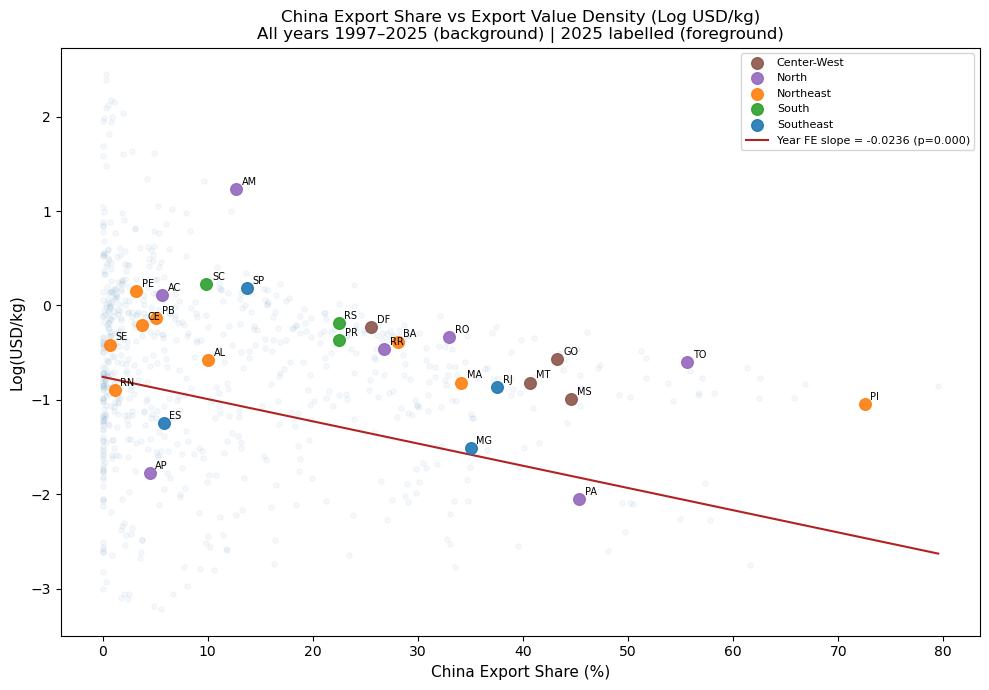

In [25]:
## Regression scatter: two-layer chart consistent with Steps 2b and 2c style
## Background: all-years faded | Foreground: MAX_YEAR labeled

region_colours = {
    'Southeast'  : '#1f77b4',
    'South'      : '#2ca02c',
    'Northeast'  : '#ff7f0e',
    'North'      : '#9467bd',
    'Center-West': '#8c564b',
}

## Add region for colour coding
df_uf_region = pd.read_sql(
    "SELECT sigla, nome_regiao FROM uf;", engine
)
df_uf_region['nome_regiao'] = df_uf_region['nome_regiao'].map(region_name_map).fillna(df_uf_region['nome_regiao'])

df_curr = df_reg[df_reg['CO_ANO'] == MAX_YEAR].merge(df_uf_region, left_on='sg_uf', right_on='sigla', how='left')
df_all  = df_reg.copy()

fig, ax = plt.subplots(figsize=(10, 7))

## Background: all years, faded
ax.scatter(
    df_all['china_share_pct'], df_all['log_usd_per_kg'],
    alpha=0.05, s=15, color='steelblue', zorder=1
)

## Foreground: MAX_YEAR, coloured by region
for region, grp in df_curr.groupby('nome_regiao'):
    ax.scatter(
        grp['china_share_pct'], grp['log_usd_per_kg'],
        alpha=0.9, s=70, color=region_colours.get(region, 'gray'),
        label=region, zorder=3
    )
    for _, row in grp.iterrows():
        ax.annotate(
            row['sg_uf'],
            (row['china_share_pct'], row['log_usd_per_kg']),
            fontsize=7, xytext=(4, 3), textcoords='offset points', zorder=4
        )

## Regression line (v2 slope, intercept-only approximation for illustration)
x_line    = np.linspace(df_all['china_share_pct'].min(), df_all['china_share_pct'].max(), 200)
slope     = model_v2.params['china_share_pct']
intercept = model_v2.params['Intercept']
ax.plot(
    x_line, intercept + slope * x_line,
    color='firebrick', linewidth=1.5, zorder=2,
    label=f'Year FE slope = {slope:.4f} (p={model_v2.pvalues["china_share_pct"]:.3f})'
)

ax.set_xlabel('China Export Share (%)', fontsize=11)
ax.set_ylabel('Log(USD/kg)', fontsize=11)
ax.set_title(
    f'China Export Share vs Export Value Density (Log USD/kg)\n'
    f'All years 1997–{MAX_YEAR} (background) | {MAX_YEAR} labelled (foreground)',
    fontsize=12
)
ax.legend(fontsize=8, loc='upper right')
plt.tight_layout()
plt.show()

#### Overview

*(Complete after running — insert slope, p-value, R², N.)* Expected direction: negative slope — states with higher China export share are associated with lower average USD/kg. If year fixed effects (v2) materially change the slope versus pooled OLS (v1), report both; if they are stable, v2 is the preferred specification. A significant negative slope formally quantifies the value-density cost of China concentration established directionally in Finding 8 (Step 3).

#### Business Relevance

*(Include if the slope is statistically significant. The coefficient translates China share into an implied USD/kg penalty — directly usable as a risk quantification input for commodity-exposed state commercial profiles.)*

---
## 4.3 — Product Complexity: NCM Diversity and State Export Baskets

Shannon entropy and NCM-level HHI measure the breadth and concentration of each state's export basket at full product granularity. These complement the SH2-level HHI from Step 2b by capturing intra-sector product diversity.

In [26]:
## State-level NCM diversity metrics for MAX_YEAR
## Join: SG_UF_NCM = uf.sigla | non-geographic filter

query_ncm_diversity = f"""
    WITH state_ncm AS (
        SELECT
            e."SG_UF_NCM",
            e."CO_NCM",
            SUM(e."VL_FOB") AS vl_fob
        FROM exp e
        JOIN uf u ON e."SG_UF_NCM" = u.sigla
        WHERE e."CO_ANO" = {MAX_YEAR}
          AND u.nome_regiao NOT IN (
            'REGIAO NAO DECLARADA',
            'CONSUMO DE BORDO',
            'MERCADORIA NACIONALIZADA',
            'REEXPORTACAO'
        )
        GROUP BY e."SG_UF_NCM", e."CO_NCM"
    ),
    state_totals AS (
        SELECT
            "SG_UF_NCM",
            SUM(vl_fob)     AS total_fob,
            COUNT("CO_NCM") AS ncm_count
        FROM state_ncm
        GROUP BY "SG_UF_NCM"
    )
    SELECT
        sn."SG_UF_NCM"               AS sg_uf,
        u.nome_regiao                AS regiao,
        st.total_fob,
        st.ncm_count,
        sn."CO_NCM",
        sn.vl_fob,
        sn.vl_fob::FLOAT / st.total_fob AS share
    FROM state_ncm sn
    JOIN state_totals st ON sn."SG_UF_NCM" = st."SG_UF_NCM"
    JOIN uf u ON sn."SG_UF_NCM" = u.sigla
    WHERE st.total_fob > 0;
"""

df_ncm_div = pd.read_sql(query_ncm_diversity, engine)
df_ncm_div['regiao'] = df_ncm_div['regiao'].map(region_name_map).fillna(df_ncm_div['regiao'])

def shannon_entropy(shares):
    ## Shannon entropy (log2) — higher = more diversified product basket
    s = shares[shares > 0]
    return -np.sum(s * np.log2(s))

def hhi(shares):
    return np.sum(shares ** 2)

diversity_metrics = (
    df_ncm_div.groupby(['sg_uf', 'regiao', 'total_fob', 'ncm_count'])['share']
    .agg(shannon=shannon_entropy, hhi_ncm=hhi)
    .reset_index()
    .sort_values('shannon', ascending=False)
)
diversity_metrics['total_fob_bn'] = diversity_metrics['total_fob'] / 1e9

print(f'State NCM diversity metrics, {MAX_YEAR}')
print(diversity_metrics[['sg_uf','regiao','total_fob_bn','ncm_count','shannon','hhi_ncm']].to_string(index=False))

State NCM diversity metrics, 2025
sg_uf      regiao  total_fob_bn  ncm_count  shannon  hhi_ncm
   SP   Southeast     71.389331       7072 7.731524 0.020656
   SC       South     12.196579       4356 6.890290 0.032244
   RS       South     21.531349       4155 6.357089 0.048921
   PR       South     23.652068       4555 6.171840 0.053282
   AM       North      0.939460       1721 4.657490 0.103227
   BA   Northeast     11.629026       1850 4.589580 0.087145
   PE   Northeast      2.539152       1199 4.506750 0.081340
   MG   Southeast     45.833362       3415 4.353341 0.143616
   CE   Northeast      2.284496       1747 4.287741 0.146376
   RR       North      0.240649       1449 4.079296 0.191560
   ES   Southeast     10.508245       2330 3.860704 0.118587
   GO Center-West     13.470304       1266 3.763724 0.180448
   AC       North      0.098826        181 3.583541 0.125952
   MS Center-West     10.754378        828 3.437236 0.164989
   DF Center-West      0.316780        321 3.348494

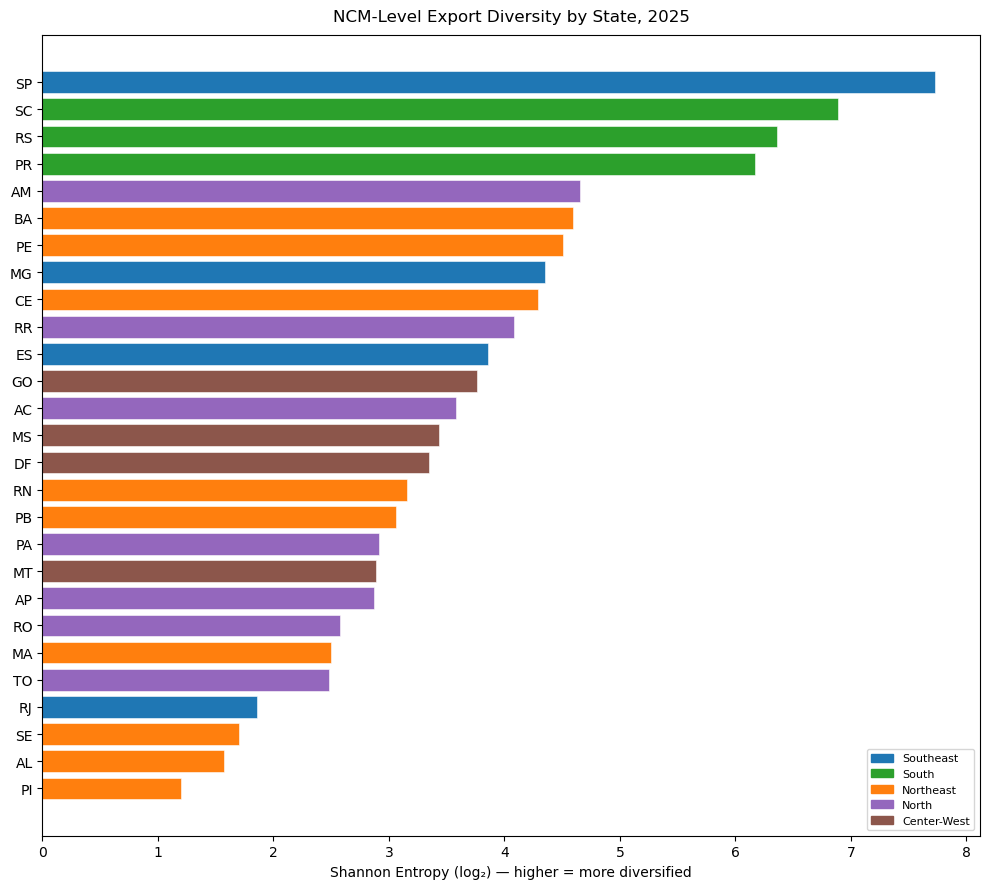

In [27]:
## Chart: NCM Shannon Entropy by State — sorted descending, coloured by region

region_colours = {
    'Southeast'  : '#1f77b4',
    'South'      : '#2ca02c',
    'Northeast'  : '#ff7f0e',
    'North'      : '#9467bd',
    'Center-West': '#8c564b',
}

df_plot  = diversity_metrics.sort_values('shannon', ascending=True)
colours  = df_plot['regiao'].map(region_colours).fillna('gray')

fig, ax = plt.subplots(figsize=(10, 9))
ax.barh(df_plot['sg_uf'], df_plot['shannon'], color=colours, edgecolor='white', linewidth=0.4)
ax.set_xlabel('Shannon Entropy (log₂) — higher = more diversified', fontsize=10)
ax.set_title(f'NCM-Level Export Diversity by State, {MAX_YEAR}', fontsize=12, pad=10)

legend_handles = [mpatches.Patch(color=c, label=r) for r, c in region_colours.items()]
ax.legend(handles=legend_handles, loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

#### Overview

*(Complete after running.)* Compare the NCM Shannon entropy ranking against the SH2-level HHI ranking from Section 2b.3. States where the two rankings diverge are analytically significant: a state with low SH2 HHI (diverse at sector level) but low Shannon entropy (concentrated at product level within those sectors) is less diversified than sector-level metrics suggest. The inverse — high SH2 HHI but high Shannon entropy — would indicate that a dominant sector actually exports a wide range of products within it.

#### Business Relevance

NCM-level diversity is a more precise counterparty risk measure than SH2-level HHI. A state with one dominant SH2 sector but high intra-sector NCM diversity has more substitutable product risk than one locked into a single NCM code — relevant for pricing export credit and logistics exposure.

---
## 4.4 — Export Basket Concentration Over Time: NCM-Level HHI Trends

Snapshot comparison of NCM-level product concentration across six benchmark years. Assesses whether within-state HHI shifts in the 2010–2025 window noted in Step 3 are visible at product level.

In [28]:
## NCM-level HHI by state for snapshot years
## Snapshot approach limits query scope on 131M row table

SNAPSHOT_YEARS = [1997, 2005, 2010, 2015, 2020, MAX_YEAR]

query_hhi_trends = f"""
    WITH state_ncm_snap AS (
        SELECT
            e."SG_UF_NCM",
            e."CO_ANO",
            e."CO_NCM",
            SUM(e."VL_FOB") AS vl_fob
        FROM exp e
        JOIN uf u ON e."SG_UF_NCM" = u.sigla
        WHERE e."CO_ANO" IN ({','.join(str(y) for y in SNAPSHOT_YEARS)})
          AND u.nome_regiao NOT IN (
            'REGIAO NAO DECLARADA',
            'CONSUMO DE BORDO',
            'MERCADORIA NACIONALIZADA',
            'REEXPORTACAO'
        )
        GROUP BY e."SG_UF_NCM", e."CO_ANO", e."CO_NCM"
    ),
    state_year_total AS (
        SELECT "SG_UF_NCM", "CO_ANO", SUM(vl_fob) AS total_fob
        FROM state_ncm_snap
        GROUP BY "SG_UF_NCM", "CO_ANO"
    )
    SELECT
        sn."SG_UF_NCM"                                       AS sg_uf,
        sn."CO_ANO",
        sn."CO_NCM",
        sn.vl_fob::FLOAT / NULLIF(sy.total_fob, 0)          AS share
    FROM state_ncm_snap sn
    JOIN state_year_total sy
        ON sn."SG_UF_NCM" = sy."SG_UF_NCM" AND sn."CO_ANO" = sy."CO_ANO";
"""

df_hhi_raw = pd.read_sql(query_hhi_trends, engine)

df_hhi_trends = (
    df_hhi_raw.groupby(['sg_uf', 'CO_ANO'])['share']
    .apply(lambda s: np.sum(s**2))
    .reset_index()
    .rename(columns={'share': 'hhi_ncm'})
)

df_hhi_pivot = (
    df_hhi_trends
    .pivot(index='sg_uf', columns='CO_ANO', values='hhi_ncm')
    .round(4)
)
df_hhi_pivot['change_1997_2025'] = df_hhi_pivot[MAX_YEAR] - df_hhi_pivot[1997]
df_hhi_pivot = df_hhi_pivot.sort_values('change_1997_2025', ascending=True)

print(f'NCM-level HHI by state — snapshot years (sorted by 1997→{MAX_YEAR} change)')
print(df_hhi_pivot.to_string())

NCM-level HHI by state — snapshot years (sorted by 1997→2025 change)
CO_ANO    1997    2005    2010    2015    2020    2025  change_1997_2025
sg_uf                                                                   
DF      0.4472  0.2787  0.2911  0.2753  0.2335  0.1611           -0.2861
RR      0.4150  0.2078  0.2424  0.6010  0.0866  0.1916           -0.2234
MA      0.3935  0.1844  0.1805  0.2397  0.1935  0.2647           -0.1288
MS      0.2855  0.1079  0.1010  0.1528  0.1775  0.1650           -0.1205
ES      0.2317  0.2438  0.3343  0.1866  0.1100  0.1186           -0.1131
MT      0.3286  0.3081  0.2200  0.2489  0.2461  0.2337           -0.0949
AC      0.2191  0.2017  0.2130  0.4485  0.0590  0.1260           -0.0931
PE      0.1683  0.0521  0.1297  0.0624  0.1018  0.0813           -0.0870
AL      0.5364  0.3470  0.6507  0.4825  0.7727  0.4617           -0.0747
PR      0.0976  0.0338  0.0530  0.0664  0.1024  0.0533           -0.0443
CE      0.1898  0.0578  0.0623  0.0498  0.2251  0.1464 

#### Overview

*(Complete after running.)* Identify which states show the largest NCM-level HHI changes across the six snapshot years. Cross-reference against the municipality-level HHI changes from Section 3.4.4 — if geographic concentration and product concentration moved in the same direction over the same period, that is a stronger structural signal than either dimension alone. The 2010–2025 sub-period connects to the Step 2c regression weakening finding.

---
## 4.5 — Paraná Trade Balance Reversal: Product and Partner Analysis

Paraná's trade balance shifted from -\\$1.51bn (2011) to +\\$3.50bn (2025). The mechanism has not been identified. This section isolates which SH2 sectors drove the shift by comparing composition at the deficit peak (2011) against MAX_YEAR.

In [29]:
## Paraná: SH2-level export and import time series, 2009–MAX_YEAR
## SG_UF_NCM = 'PR'

query_pr_exp_sh2 = f"""
    SELECT
        e."CO_ANO",
        sh.codigo_sh2,
        sh.descricao_sh2                                     AS sh2_description,
        SUM(e."VL_FOB")                                      AS exp_fob
    FROM exp e
    LEFT JOIN ncm n  ON e."CO_NCM" = n.codigo_ncm
    LEFT JOIN ncm_sh sh ON n.codigo_sh6 = sh.codigo_sh6
    WHERE e."SG_UF_NCM" = 'PR'
      AND e."CO_ANO" BETWEEN 2009 AND {MAX_YEAR}
    GROUP BY e."CO_ANO", sh.codigo_sh2, sh.descricao_sh2
    ORDER BY e."CO_ANO", exp_fob DESC;
"""

query_pr_imp_sh2 = f"""
    SELECT
        i."CO_ANO",
        sh.codigo_sh2,
        sh.descricao_sh2                                     AS sh2_description,
        SUM(i."VL_FOB")                                      AS imp_fob
    FROM imp i
    LEFT JOIN ncm n  ON i."CO_NCM" = n.codigo_ncm
    LEFT JOIN ncm_sh sh ON n.codigo_sh6 = sh.codigo_sh6
    WHERE i."SG_UF_NCM" = 'PR'
      AND i."CO_ANO" BETWEEN 2009 AND {MAX_YEAR}
    GROUP BY i."CO_ANO", sh.codigo_sh2, sh.descricao_sh2
    ORDER BY i."CO_ANO", imp_fob DESC;
"""

df_pr_exp = pd.read_sql(query_pr_exp_sh2, engine)
df_pr_imp = pd.read_sql(query_pr_imp_sh2, engine)

## Annual totals
pr_exp_annual = df_pr_exp.groupby('CO_ANO')['exp_fob'].sum() / 1e9
pr_imp_annual = df_pr_imp.groupby('CO_ANO')['imp_fob'].sum() / 1e9
pr_balance    = (pr_exp_annual - pr_imp_annual).round(2)

print(f'Paraná annual trade balance (\$bn), 2009–{MAX_YEAR}')
print(pd.DataFrame({'exports_bn': pr_exp_annual.round(2), 'imports_bn': pr_imp_annual.round(2), 'balance_bn': pr_balance}))

Paraná annual trade balance (\$bn), 2009–2025
        exports_bn  imports_bn  balance_bn
CO_ANO                                    
2009         11.13        9.64        1.49
2010         14.04       13.96        0.08
2011         17.29       18.80       -1.51
2012         17.62       19.49       -1.87
2013         18.10       19.43       -1.33
2014         16.24       17.33       -1.09
2015         14.83       12.49        2.34
2016         15.01       11.17        3.85
2017         17.93       12.68        5.25
2018         18.10       14.10        4.00
2019         16.40       14.42        1.98
2020         16.26       11.88        4.38
2021         19.03       16.97        2.06
2022         22.13       22.40       -0.27
2023         25.28       18.18        7.10
2024         23.35       19.59        3.75
2025         23.65       20.15        3.50


In [30]:
## Compare top SH2 export sectors: 2011 (deficit peak) vs MAX_YEAR (surplus)

for year in [2011, MAX_YEAR]:
    df_exp_yr = df_pr_exp[df_pr_exp['CO_ANO'] == year].sort_values('exp_fob', ascending=False).head(10)
    df_imp_yr = df_pr_imp[df_pr_imp['CO_ANO'] == year].sort_values('imp_fob', ascending=False).head(5)
    df_exp_yr = df_exp_yr.copy()
    df_exp_yr['exp_fob_bn'] = df_exp_yr['exp_fob'] / 1e9
    df_imp_yr = df_imp_yr.copy()
    df_imp_yr['imp_fob_bn'] = df_imp_yr['imp_fob'] / 1e9
    print(f'\nParaná top export sectors, {year}:')
    print(df_exp_yr[['codigo_sh2','sh2_description','exp_fob_bn']].to_string(index=False))
    print(f'\nParaná top import sectors, {year}:')
    print(df_imp_yr[['codigo_sh2','sh2_description','imp_fob_bn']].to_string(index=False))


Paraná top export sectors, 2011:
 codigo_sh2                                                                                                                       sh2_description  exp_fob_bn
         12               Sementes e frutos oleaginosos; grãos, sementes e frutos diversos; plantas industriais ou medicinais; palhas e forragens    3.384931
          2                                                                                                        Carnes e miudezas, comestíveis    2.181070
         87                                          Veículos automóveis, tratores, ciclos e outros veículos terrestres, suas partes e acessórios    1.844399
         17                                                                                                    Açúcares e produtos de confeitaria    1.505737
         23                                                 Resíduos e desperdícios das indústrias alimentares; alimentos preparados para animais    1.410519
         84       

#### Overview

*(Complete after running.)* Identify the specific SH2 sectors driving Paraná's shift from deficit to surplus. The likely mechanism is agricultural export expansion (SH12 soybeans, SH10 cereals) outpacing import growth in the same period — but the query will confirm whether import contraction in specific sectors also contributed. Report 2011 vs 2025 sector composition changes with absolute values for the sectors that moved most.

#### Business Relevance

The Paraná reversal mechanism, once identified, provides a template for assessing whether comparable balance shifts are possible in other deficit states with similar profiles.

---
## 4.6 — China Share by National Sector

China's share of each major national export sector — quantifying the commodity-sector concentration of the Brazil–China relationship at SH2 level.

In [31]:
## National China share by SH2 sector
## Join ncm → ncm_sh via codigo_sh6 to get descricao_sh2

query_china_sector = f"""
    WITH sector_totals AS (
        SELECT
            n.codigo_sh6,
            SUM(e."VL_FOB") AS total_fob
        FROM exp e
        JOIN ncm n ON e."CO_NCM" = n.codigo_ncm
        WHERE e."CO_ANO" = {MAX_YEAR}
        GROUP BY n.codigo_sh6
    ),
    china_by_sector AS (
        SELECT
            n.codigo_sh6,
            SUM(e."VL_FOB") AS china_fob
        FROM exp e
        JOIN ncm n ON e."CO_NCM" = n.codigo_ncm
        WHERE e."CO_ANO"  = {MAX_YEAR}
          AND e."CO_PAIS" = {CHINA_CODE}
        GROUP BY n.codigo_sh6
    ),
    sh2_agg AS (
        SELECT
            sh.codigo_sh2,
            sh.descricao_sh2,
            SUM(st.total_fob)                AS total_fob,
            SUM(COALESCE(cs.china_fob, 0))   AS china_fob
        FROM sector_totals st
        LEFT JOIN china_by_sector cs ON st.codigo_sh6 = cs.codigo_sh6
        LEFT JOIN ncm_sh sh          ON st.codigo_sh6 = sh.codigo_sh6
        GROUP BY sh.codigo_sh2, sh.descricao_sh2
    )
    SELECT
        codigo_sh2,
        descricao_sh2,
        total_fob,
        china_fob,
        ROUND(100.0 * china_fob / NULLIF(total_fob, 0), 2) AS china_share_pct
    FROM sh2_agg
    ORDER BY total_fob DESC
    LIMIT 30;
"""

df_china_sector = pd.read_sql(query_china_sector, engine)
df_china_sector['total_fob_bn'] = df_china_sector['total_fob'] / 1e9
df_china_sector['china_fob_bn'] = df_china_sector['china_fob'] / 1e9

print(f'National China share by SH2 export sector, {MAX_YEAR}')
print(df_china_sector[['codigo_sh2','descricao_sh2','total_fob_bn','china_fob_bn','china_share_pct']].to_string(index=False))

National China share by SH2 export sector, 2025
 codigo_sh2                                                                                                                                                                                                descricao_sh2  total_fob_bn  china_fob_bn  china_share_pct
         27                                                                                                     Combustíveis minerais, óleos minerais e produtos da sua destilação; matérias betuminosas; ceras minerais     55.955256     20.548301            36.72
         12                                                                                      Sementes e frutos oleaginosos; grãos, sementes e frutos diversos; plantas industriais ou medicinais; palhas e forragens     44.672157     34.756442            77.80
         26                                                                                                                                                           

#### Overview

*(Complete after running.)* Report China share for all major export sectors. Expected pattern: soybeans, iron ore and copper at 60–80% China share; manufactured goods (vehicles, aircraft, machinery) at < 5%. The sector-level China share table is the national counterpart to the state-level China dependency analysis in Section 2.7 — it shows which products, not which states, drive the Brazil-China relationship.

#### Business Relevance

Sectors above 50% China share carry concentrated destination risk. Any sustained reduction in Chinese demand — policy-driven, structural, or cyclical — flows directly to those sectors' export volumes and FOB values with limited short-term diversion capacity.

---
## 4.7 — Anchieta and Aracruz (Espírito Santo): Export Destination Markets

In [32]:
## Anchieta and Aracruz: SH4-level export profile + partner breakdown from exp_mun
## CO_MUN: Anchieta = 3200904, Aracruz = 3200607 — verify against uf_mun

for mun_code, mun_name in [(3200904, 'Anchieta'), (3200607, 'Aracruz')]:

    ## SH4 export profile
    query_mun_sh4 = f"""
        WITH mun_exp AS (
            SELECT
                em."SH4",
                SUM(em."VL_FOB")     AS vl_fob
            FROM exp_mun em
            WHERE em."CO_MUN" = {mun_code}
              AND em."CO_ANO" = {MAX_YEAR}
            GROUP BY em."SH4"
        )
        SELECT
            m."SH4",
            sh.descricao_sh4   AS sh4_description,
            m.vl_fob,
            ROUND(100.0 * m.vl_fob / SUM(m.vl_fob) OVER (), 2) AS pct_of_total
        FROM mun_exp m
        LEFT JOIN ncm_sh sh ON m."SH4" = sh.codigo_sh4
        ORDER BY m.vl_fob DESC
        LIMIT 10;
    """

    ## Partner breakdown
    query_mun_partners = f"""
        WITH mun_partners AS (
            SELECT
                em."CO_PAIS",
                SUM(em."VL_FOB") AS vl_fob
            FROM exp_mun em
            WHERE em."CO_MUN" = {mun_code}
              AND em."CO_ANO" = {MAX_YEAR}
            GROUP BY em."CO_PAIS"
        )
        SELECT
            m."CO_PAIS",
            p.nome_pais                                              AS partner_country,
            m.vl_fob,
            ROUND(100.0 * m.vl_fob / SUM(m.vl_fob) OVER (), 2)     AS pct_of_total
        FROM mun_partners m
        LEFT JOIN pais p ON m."CO_PAIS" = p.codigo_pais
        ORDER BY m.vl_fob DESC
        LIMIT 10;
    """

    df_sh4   = pd.read_sql(query_mun_sh4, engine)
    df_parts = pd.read_sql(query_mun_partners, engine)
    df_sh4['vl_fob_bn']   = df_sh4['vl_fob'] / 1e9
    df_parts['vl_fob_bn'] = df_parts['vl_fob'] / 1e9

    print(f'\n{mun_name} (ES) — SH4 export profile, {MAX_YEAR}')
    print(df_sh4[['SH4','sh4_description','vl_fob_bn','pct_of_total']].to_string(index=False))
    print(f'\n{mun_name} (ES) — export destination markets, {MAX_YEAR}')
    print(df_parts[['partner_country','vl_fob_bn','pct_of_total']].to_string(index=False))


Anchieta (ES) — SH4 export profile, 2025
 SH4                                                                                                                                                                                                                                               sh4_description  vl_fob_bn  pct_of_total
6802 Pedras de cantaria ou de construção (exceto de ardósia) trabalhadas e obras destas pedras, exceto as da posição 6801; cubos, pastilhas e artigos semelhantes, para mosaicos, de pedra natural (incluída a ardósia), mesmo com suporte; grânulos, fragmentos e   0.110365          8.76
6802 Pedras de cantaria ou de construção (exceto de ardósia) trabalhadas e obras destas pedras, exceto as da posição 6801; cubos, pastilhas e artigos semelhantes, para mosaicos, de pedra natural (incluída a ardósia), mesmo com suporte; grânulos, fragmentos e   0.110365          8.76
6802 Pedras de cantaria ou de construção (exceto de ardósia) trabalhadas e obras destas pedras, exceto as 

#### Overview

*(Complete after running.)* Confirm the SH4 export profile and destination markets for each municipality. Anchieta is expected to show iron ore and steel products; Aracruz is expected to show pulp (SH47). The key question from Step 2 is whether China's share of ore and pulp from these municipalities is below the national average — confirm or revise the 9.6% and 17.5% figures cited in the Step 2 open investigation.

---
## 4.8 — Marabá: Iron Ore China Share Investigation

In [33]:
## Marabá: SH4 export profile and China share
## CO_MUN for Marabá (PA): 1504208

query_maraba_sh4 = f"""
    WITH maraba_exp AS (
        SELECT
            em."SH4",
            em."CO_PAIS",
            SUM(em."VL_FOB")     AS vl_fob,
            SUM(em."KG_LIQUIDO") AS kg_liq
        FROM exp_mun em
        WHERE em."CO_MUN" = 1504208
          AND em."CO_ANO" = {MAX_YEAR}
        GROUP BY em."SH4", em."CO_PAIS"
    )
    SELECT
        m."SH4",
        sh.descricao_sh4   AS sh4_description,
        sh.descricao_sh2   AS sh2_description,
        m."CO_PAIS",
        p.nome_pais        AS partner_country,
        m.vl_fob,
        m.kg_liq,
        ROUND(100.0 * m.vl_fob / SUM(m.vl_fob) OVER (), 2) AS pct_of_total
    FROM maraba_exp m
    LEFT JOIN ncm_sh sh ON m."SH4" = sh.codigo_sh4
    LEFT JOIN pais p    ON m."CO_PAIS" = p.codigo_pais
    ORDER BY m.vl_fob DESC
    LIMIT 20;
"""

df_maraba = pd.read_sql(query_maraba_sh4, engine)
df_maraba['vl_fob_bn'] = df_maraba['vl_fob'] / 1e9

## China share at municipality level
maraba_total = df_maraba['vl_fob'].sum()
maraba_china = df_maraba[df_maraba['CO_PAIS'] == CHINA_CODE]['vl_fob'].sum()
print(f'Marabá — SH4 + partner breakdown, {MAX_YEAR}')
print(f'China share: {100*maraba_china/maraba_total:.1f}% (confirms/revises 9.9% from Step 3)')
print(df_maraba[['SH4','sh4_description','partner_country','vl_fob_bn','pct_of_total']].to_string(index=False))

Marabá — SH4 + partner breakdown, 2025
China share: 13.2% (confirms/revises 9.9% from Step 3)
 SH4                                                                                    sh4_description  partner_country  vl_fob_bn  pct_of_total
2603                                                              Minérios de cobre e seus concentrados         Alemanha   0.546411         14.18
2603                                                              Minérios de cobre e seus concentrados          Polônia   0.500224         12.98
2603                                                              Minérios de cobre e seus concentrados         Bulgária   0.450880         11.70
2603                                                              Minérios de cobre e seus concentrados          Malásia   0.300614          7.80
2603                                                              Minérios de cobre e seus concentrados           Suécia   0.278130          7.22
2603                          

#### Overview

*(Complete after running.)* Confirm or revise the 9.9% China share figure from Step 3. If Marabá's export profile includes processed steel products (SH72) alongside iron ore (SH26), that explains the lower China routing — processed steel routes to different markets than raw ore. The SH4 partner breakdown will reveal whether the non-China routing is to identifiable end markets.

---
## 4.9 — Post-2015 Deficit Convergence: Municipality-Level Time Series

Multiple municipalities entered deficit positions in the 2015–2025 window, parallel to the post-2015 regression weakening in Step 2c. This section maps the timing of deficit emergence across the top deficit municipalities to assess whether convergence is systematic.

In [34]:
## Step 1: Identify top 20 deficit municipalities in MAX_YEAR

query_top_deficit = f"""
    WITH exp_tot AS (
        SELECT "CO_MUN", SUM("VL_FOB") AS exp_fob
        FROM exp_mun
        WHERE "CO_ANO" = {MAX_YEAR}
        GROUP BY "CO_MUN"
    ),
    imp_tot AS (
        SELECT "CO_MUN", SUM("VL_FOB") AS imp_fob
        FROM imp_mun
        WHERE "CO_ANO" = {MAX_YEAR}
        GROUP BY "CO_MUN"
    )
    SELECT
        COALESCE(e."CO_MUN", m."CO_MUN")            AS co_mun,
        COALESCE(e.exp_fob, 0)                       AS exp_fob,
        COALESCE(m.imp_fob, 0)                       AS imp_fob,
        COALESCE(e.exp_fob, 0) - COALESCE(m.imp_fob, 0) AS balance
    FROM exp_tot e
    FULL OUTER JOIN imp_tot m ON e."CO_MUN" = m."CO_MUN"
    ORDER BY balance ASC
    LIMIT 20;
"""

df_top_deficit = pd.read_sql(query_top_deficit, engine)
df_top_deficit['balance_bn'] = df_top_deficit['balance'] / 1e9
top_muns = df_top_deficit['co_mun'].tolist()

print(f'Top 20 deficit municipalities, {MAX_YEAR}')
print(df_top_deficit[['co_mun','balance_bn']].to_string(index=False))

Top 20 deficit municipalities, 2025
 co_mun  balance_bn
1302603  -15.031417
4208203  -10.190766
3303906   -8.870907
3201308   -7.031616
3450308   -5.407155
3436505   -5.384450
3425904   -3.346616
4209102   -3.162759
2111300   -2.542416
3125101   -2.537791
3409502   -2.190251
4125506   -2.180133
5400108   -2.176364
2905701   -2.146884
2607208   -2.129493
5301108   -2.064072
3405708   -1.999759
1100205   -1.752597
4106902   -1.511318
4201307   -1.382699


In [35]:
## Step 2: Annual balance time series for these municipalities

mun_list_sql = ','.join(str(m) for m in top_muns)

query_deficit_ts = f"""
    WITH exp_ts AS (
        SELECT "CO_MUN", "CO_ANO", SUM("VL_FOB") AS exp_fob
        FROM exp_mun
        WHERE "CO_MUN" IN ({mun_list_sql})
        GROUP BY "CO_MUN", "CO_ANO"
    ),
    imp_ts AS (
        SELECT "CO_MUN", "CO_ANO", SUM("VL_FOB") AS imp_fob
        FROM imp_mun
        WHERE "CO_MUN" IN ({mun_list_sql})
        GROUP BY "CO_MUN", "CO_ANO"
    )
    SELECT
        COALESCE(e."CO_MUN", m."CO_MUN")            AS co_mun,
        COALESCE(e."CO_ANO", m."CO_ANO")            AS co_ano,
        COALESCE(e.exp_fob, 0)                       AS exp_fob,
        COALESCE(m.imp_fob, 0)                       AS imp_fob,
        COALESCE(e.exp_fob, 0) - COALESCE(m.imp_fob, 0) AS balance
    FROM exp_ts e
    FULL OUTER JOIN imp_ts m
        ON e."CO_MUN" = m."CO_MUN" AND e."CO_ANO" = m."CO_ANO"
    ORDER BY co_mun, co_ano;
"""

df_deficit_ts = pd.read_sql(query_deficit_ts, engine)

## First year each municipality entered deficit
first_deficit = (
    df_deficit_ts[df_deficit_ts['balance'] < 0]
    .groupby('co_mun')['co_ano']
    .min()
    .reset_index()
    .rename(columns={'co_ano': 'first_deficit_year'})
    .sort_values('first_deficit_year')
)

print('First deficit year by municipality (top 20 deficit in 2025):')
print(first_deficit.to_string(index=False))

## Count of new deficit entries by period
bins   = [0, 2000, 2010, 2015, 2020, 2025]
labels = ['pre-2000','2001–2010','2011–2015','2016–2020','2021–2025']
first_deficit['period'] = pd.cut(first_deficit['first_deficit_year'], bins=bins, labels=labels)
print('\nNew deficit entries by period (top-20 deficit municipalities):')
print(first_deficit['period'].value_counts().sort_index())

First deficit year by municipality (top 20 deficit in 2025):
 co_mun  first_deficit_year
1100205                1997
4125506                1997
4106902                1997
3450308                1997
3436505                1997
3425904                1997
5301108                1997
3405708                1997
3409502                1997
3201308                1997
3125101                1997
2607208                1997
1302603                1997
3303906                1997
5400108                1997
4201307                1998
2905701                2000
2111300                2001
4208203                2009
4209102                2010

New deficit entries by period (top-20 deficit municipalities):
period
pre-2000     17
2001–2010     3
2011–2015     0
2016–2020     0
2021–2025     0
Name: count, dtype: int64


#### Overview

*(Complete after running.)* Report the distribution of deficit entry years across the five time periods. If the 2011–2015 or 2016–2020 window contains a disproportionate share of new deficit entries among the top-20 deficit municipalities, that confirms the parallel with the Step 2c regression weakening is not coincidental. The mechanism remains unidentified — flag for external data investigation in Steps 8 and 9.

---
## 4.10 — Open Flag Resolution Summary

*(Complete after all sections above are executed. Mark each flag as Resolved, Partially Resolved, or Remains Open with a one-sentence conclusion.)*

| Flag | Section | Status | Conclusion |
|---|---|---|---|
| Petrópolis \\$9.47bn import anomaly | 4.1.1 | TBC | |
| Itajaí \\$-10.19bn deficit | 4.1.2 | TBC | |
| Cariacica vehicle imports | 4.1.3 | TBC | |
| SH27 crude vs refined split | 4.1.4 | TBC | |
| Ferro-niobium national total + partners | 4.1.5 | TBC | |
| Cotton destination markets (MT) | 4.1.6 | TBC | |
| Tobacco destination markets (RS) | 4.1.7 | TBC | |
| Goiás pharmaceutical imports | 4.1.8 | TBC | |
| Piauí and RJ product HHI drivers | 4.1.9 | TBC | |
| Rio Grande do Norte / Panama | 4.1.10 | TBC | |
| Vehicle import composition (national) | 4.1.11 | TBC | |
| Manufactured goods buyers | 4.1.12 | TBC | |
| China share vs USD/kg regression | 4.2 | TBC | |
| Paraná balance reversal | 4.5 | TBC | |
| Post-2015 deficit convergence | 4.9 | TBC | |
| Marabá 9.9% China share | 4.8 | TBC | |
| Anchieta / Aracruz routing | 4.7 | TBC | |

---
## 4.11 — Key Findings

*(Complete after all sections above are executed. Structure: numbered findings, directly traceable to data, no speculation. Flag any mechanisms that remain unconfirmed with ⚠️.)*